In [114]:
!pip install causalml plotly scipy statsmodels skimpy hmmlearn hdbscan polars dowhy shap mlflow scikit-survival umap-learn xgboost lightgbm catboost imblearn econml graphviz pygraphviz pydot

  Using cached econml-0.16.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (37 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.0/106.0 kB 3.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of econml to determine which version is compatible with other requirements. This could take a while.
  Using cached econml-0.15.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (38 kB)
  Using cached econml-0.15.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (36 kB)
  Using cached econml-0.14.1.tar.gz (1.4 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached econml-0.14.0.tar.gz (1.4 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing m

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import polars as pl
import os
import scipy.stats as ss
import statsmodels.tsa.api as sts
from scipy.special import softmax
from scipy.stats import norm
from scipy.stats import rankdata
import skimpy as sk
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import wilcoxon
import causalml
import dowhy
import shap
import mlflow
import hdbscan
import mlflow.sklearn
import plotly.graph_objects as go
import hmmlearn
from imblearn.over_sampling import ADASYN
from sklearn.inspection import permutation_importance
from dowhy import CausalModel
from econml.dml import CausalForestDML


from sklearn.decomposition import PCA
import umap.umap_ as umap
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import *
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import *
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.mixture import GaussianMixture
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from catboost import CatBoostError # Add this line

import sksurv
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest
from sklearn.linear_model import *
from sklearn.ensemble import *
from sklearn.naive_bayes import *

import joblib
from warnings import filterwarnings; filterwarnings("ignore")

ModuleNotFoundError: No module named 'econml'

## Problem Reframe

The problem was reframed as a weather condition classification task to mitigate the confounding influence of temperature-related variables on the target label (condition_text). Temperature was assumed to have a dominant causal relationship with weather conditions, which could bias the model toward shortcut learning and reduce interpretability of geographic and atmospheric predictors. Excluding these variables promotes a more causally informed and ethically interpretable modeling framework.

(For Scientific Audience)
- Temperature variables were excluded due to their assumed role as high-influence confounders and mediators between geographic factors and weather conditions. Retaining these variables could obscure the contribution of spatial and environmental predictors, leading to biased attribution and reduced interpretability.


In [38]:
cols_to_drop = [
    'temperature_fahrenheit',
    'feels_like_fahrenheit',
    'wind_mph',
    'gust_mph',
    'pressure_in',
    'precip_in',
    'visibility_miles',
    'temperature_celsius',
    'feels_like_celsius',
    'last_updated',
    'location_name',
     'country',
    'timezone',
    'sunrise',
    'sunset',
    'moonrise',
    'moonset',
    'moon_phase',
    'moon_illumination'
]

df = pd.read_csv("/content/GlobalWeatherRepository.csv").drop(columns=cols_to_drop, axis=1)


In [39]:
df.columns

Index(['latitude', 'longitude', 'last_updated_epoch', 'condition_text',
       'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'precip_mm',
       'humidity', 'cloud', 'visibility_km', 'uv_index', 'gust_kph',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
       'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index',
       'air_quality_gb-defra-index'],
      dtype='object')

## Thought process:
Through the use of skimpy, we simplify the analysis of missing data, NaNs, outliers and data dsitribution. The Data Moves in a Fat Tailed scenario.

In [40]:
sk.skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 3119   │ │ float64     │ 14    │                                                          │
│ │ Number of columns │ 22     │ │ int64       │ 6     │                                                          │
│ └───────────────────┴────────┘ │ string      │ 2     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column   ┃ NA ┃ NA % ┃ mean     ┃ sd     ┃ p0       ┃ p25      ┃ p50       ┃ p75      ┃ p100      ┃ hist   ┃  │
│ ┡━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━┩  │
│ │ latitude │  0 │    0 │    19.31 │  24.58 │    -41.3 │     3.75 │     17.25 │    41.33 │     63.83 │ ▂▃▆██▅ │  │
│ │ longitud │  0 │    0 │    21.81 │  65.66 │   -175.2 │    -6.84 │     23.24 │    50.58 │     179.2 │  ▃▂█▂▁ │  │
│ │ e        │    │      │          │        │          │          │           │          │           │        │  │
│ │ last_upd │  0 │    0 │ 16940000 │ 392500 │ 16930000 │ 16940000 │ 169400000 │ 16940000 │ 169500000 │ ██▅█▅█ │  │
│ │ ated_epo │    │      │       00 │        │       00 │       00 │         0 │       00 │         0 │        │  │
│ │ ch       │    │      │          │        │          │          │           │          │           │        │  │
│ │ wind_kph │  0 │    0 │    10.48 │  7.257 │      3.6 │      4.7 │       8.6 │     14.4 │      70.6 │   █▂   │  │
│ │ wind_deg │  0 │    0 │      163 │    103 │        1 │       75 │       157 │      240 │       360 │ ██▆▇▅▅ │  │
│ │ ree      │    │      │          │        │          │          │           │          │           │        │  │
│ │ pressure │  0 │    0 │     1013 │  5.775 │      992 │     1010 │      1013 │     1017 │      1036 │  ▂██▂  │  │
│ │ _mb      │    │      │          │        │          │          │           │          │           │        │  │
│ │ precip_m │  0 │    0 │   0.2155 │  1.156 │        0 │        0 │         0 │        0 │        31 │   █    │  │
│ │ m        │    │      │          │        │          │          │           │          │           │        │  │
│ │ humidity │  0 │    0 │    73.28 │   20.4 │        6 │       64 │        78 │       89 │       100 │  ▂▂▃█▇ │  │
│ │ cloud    │  0 │    0 │    32.87 │  32.18 │        0 │        0 │        25 │       61 │       100 │ █▄▁▃▄▁ │  │
│ │ visibili │  0 │    0 │     9.79 │  2.582 │        0 │       10 │        10 │       10 │        32 │    █   │  │
│ │ ty_km    │    │      │          │        │          │          │           │          │           │        │  │
│ │ uv_index │  0 │    0 │     2.28 │  2.283 │        1 │        1 │         1 │        3 │        10 │ █ ▁▁▁  │  │
│ │ gust_kph │  0 │    0 │    17.04 │  10.93 │        0 │        9 │      15.1 │     22.5 │     110.5 │  █▄▁   │  │
│ │ air_qual │  0 │    0 │    488.4 │  956.5 │    123.5 │    223.6 │     270.4 │    427.3 │     18160 │   █    │  │
│ │ ity_Carb │    │      │          │        │          │          │           │          │           │        │  │
│ │ on_Monox │    │      │          │        │          

In [41]:
train_size = 0.8
split_index = int(len(df) * train_size)

train = df.iloc[:split_index, :]
test = df.iloc[split_index:, :]

In [42]:
train

,latitude,longitude,last_updated_epoch,condition_text,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,...,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index
0,34.52,69.18,1693301400,Sunny,11.5,74,ENE,1004.0,0.0,19,...,7.0,13.3,647.5,130.2,1.2,0.4,7.9,11.1,1,1
1,41.33,19.82,1693301400,Partly cloudy,6.1,210,SSW,1006.0,0.0,54,...,6.0,11.9,433.9,104.4,3.6,1.8,28.2,29.6,2,3
2,36.76,3.05,1693301400,Partly cloudy,13.0,240,WSW,1014.0,0.0,30,...,7.0,5.4,647.5,16.6,63.1,12.6,6.4,7.9,1,1
3,42.50,1.52,1693301400,Sunny,9.7,345,NNW,1015.0,0.0,51,...,4.0,11.9,190.3,68.0,0.2,0.2,0.5,0.8,1,1
4,-8.84,13.23,1693301400,Partly cloudy,3.6,270,W,1016.0,0.0,69,...,6.0,5.8,2136.2,147.3,52.8,26.9,139.6,203.3,4,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2490,24.64,46.77,1694299500,Clear,4.0,210,SSW,1009.0,0.0,12,...,1.0,19.1,333.8,51.5,55.5,41.0,34.9,87.1,2,3
2491,14.67,-17.44,1694299500,Partly cloudy,15.1,280,W,1013.0,0.0,84,...,1.0,31.0,303.8,32.5,0.5,0.3,6.8,26.4,1,1
2492,44.80,20.47,1694299500,Clear,6.1,210,SSW,1019.0,0.0,68,...,1.0,5.4,220.3,3.3,12.2,0.3,11.3,15.7,1,1
2493,-4.62,55.45,1694300400,Partly cloudy,25.9,140,SE,1011.0,0.1,79,...,1.0,45.0,190.3,33.6,0.2,0.5,4.2,7.7,1,1


In [43]:
np.unique(train["condition_text"])

array(['Clear', 'Cloudy', 'Fog', 'Heavy rain', 'Heavy rain at times',
       'Light drizzle', 'Light rain', 'Light rain shower', 'Mist',
       'Moderate or heavy rain shower',
       'Moderate or heavy rain with thunder', 'Moderate rain',
       'Moderate rain at times', 'Overcast', 'Partly cloudy',
       'Patchy light drizzle', 'Patchy light rain',
       'Patchy light rain with thunder', 'Patchy rain possible', 'Sunny',
       'Thundery outbreaks possible', 'Torrential rain shower'],
      dtype=object)

In [44]:
test

,latitude,longitude,last_updated_epoch,condition_text,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,...,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index
2495,1.29,103.86,1694299500,Partly cloudy,6.8,230,SW,1010.0,0.6,89,...,1.0,14.4,400.5,30.4,16.5,11.0,13.0,14.6,1,2
2496,48.15,17.12,1694299500,Clear,6.1,60,ENE,1020.0,0.0,77,...,1.0,15.1,243.7,50.8,10.3,1.2,12.0,13.4,1,2
2497,46.06,14.51,1694299500,Clear,6.8,290,WNW,1022.0,0.0,94,...,1.0,4.7,333.8,29.7,25.7,2.4,30.5,38.1,2,3
2498,-9.43,159.95,1694300400,Partly cloudy,6.1,180,S,1011.0,0.0,84,...,7.0,9.0,183.6,47.9,0.8,0.8,1.2,3.8,1,1
2499,2.07,45.37,1694300400,Partly cloudy,25.2,204,SSW,1012.0,0.0,87,...,1.0,36.4,220.3,57.2,0.1,0.2,3.5,14.6,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3114,10.50,-66.92,1694558700,Clear,6.8,350,N,1008.0,0.0,66,...,6.0,10.4,841.1,145.9,57.6,106.8,46.1,48.1,3,5
3115,21.03,105.85,1694558700,Light rain,13.0,300,WNW,1005.0,3.6,94,...,1.0,19.8,1321.8,7.2,24.3,7.0,45.2,48.9,3,5
3116,15.35,44.21,1694558700,Clear,6.8,332,NNW,1013.0,0.0,44,...,1.0,12.6,223.6,50.1,11.7,16.5,29.8,73.6,2,3
3117,-15.42,28.28,1694558700,Clear,15.8,120,ESE,1015.0,0.0,39,...,1.0,26.3,907.9,78.7,3.3,4.9,20.6,26.9,2,2


## Data Preprocessing

In [45]:
#labeling
weather_label_map = { #0 = Good, 1 = Moderate, 2 = Bad
    # GOOD WEATHER
    'Clear': 'Good',
    'Sunny': 'Good',
    'Partly cloudy': 'Good',

    # MODERATE WEATHER
    'Cloudy': 'Moderate',
    'Overcast': 'Moderate',
    'Mist': 'Moderate',
    'Fog': 'Moderate',
    'Patchy rain possible': 'Moderate',
    'Patchy light drizzle': 'Moderate',
    'Patchy light rain': 'Moderate',
    'Light drizzle': 'Moderate',
    'Light rain': 'Moderate',
    'Light rain shower': 'Moderate',
    'Moderate rain at times': 'Moderate',
    'Moderate rain': 'Moderate',
    'Thundery outbreaks possible': 'Moderate',
    'Patchy light rain with thunder': 'Moderate',

    # BAD WEATHER
    'Heavy rain': 'Bad',
    'Heavy rain at times': 'Bad',
    'Moderate or heavy rain shower': 'Bad',
    'Moderate or heavy rain with thunder': 'Bad',
    'Torrential rain shower': 'Bad'
}

general_weather_encoding = {
    'Good': 0,
    'Moderate': 1,
    'Bad': 2
}

train["condition_text"] = train["condition_text"].map(weather_label_map)
train["condition_text"] = train["condition_text"].map(general_weather_encoding)


test["condition_text"] = test["condition_text"].map(weather_label_map)
test["condition_text"] = test["condition_text"].map(general_weather_encoding)

In [46]:
train

,latitude,longitude,last_updated_epoch,condition_text,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,...,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index
0,34.52,69.18,1693301400,0,11.5,74,ENE,1004.0,0.0,19,...,7.0,13.3,647.5,130.2,1.2,0.4,7.9,11.1,1,1
1,41.33,19.82,1693301400,0,6.1,210,SSW,1006.0,0.0,54,...,6.0,11.9,433.9,104.4,3.6,1.8,28.2,29.6,2,3
2,36.76,3.05,1693301400,0,13.0,240,WSW,1014.0,0.0,30,...,7.0,5.4,647.5,16.6,63.1,12.6,6.4,7.9,1,1
3,42.50,1.52,1693301400,0,9.7,345,NNW,1015.0,0.0,51,...,4.0,11.9,190.3,68.0,0.2,0.2,0.5,0.8,1,1
4,-8.84,13.23,1693301400,0,3.6,270,W,1016.0,0.0,69,...,6.0,5.8,2136.2,147.3,52.8,26.9,139.6,203.3,4,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2490,24.64,46.77,1694299500,0,4.0,210,SSW,1009.0,0.0,12,...,1.0,19.1,333.8,51.5,55.5,41.0,34.9,87.1,2,3
2491,14.67,-17.44,1694299500,0,15.1,280,W,1013.0,0.0,84,...,1.0,31.0,303.8,32.5,0.5,0.3,6.8,26.4,1,1
2492,44.80,20.47,1694299500,0,6.1,210,SSW,1019.0,0.0,68,...,1.0,5.4,220.3,3.3,12.2,0.3,11.3,15.7,1,1
2493,-4.62,55.45,1694300400,0,25.9,140,SE,1011.0,0.1,79,...,1.0,45.0,190.3,33.6,0.2,0.5,4.2,7.7,1,1


In [47]:
train_cols = [c for c in train.columns if c != 'condition_text']
test_cols = [c for c in test.columns if c != 'condition_text']
le = {}

for col in train_cols:
  if train[col].dtype == 'object':
    le[col] = LabelEncoder()
    train[col] = le[col].fit_transform(train[[col]]).ravel()

for col in test_cols:
  if test[col].dtype == 'object':
    test[col] = le[col].transform(test[[col]]).ravel()

In [48]:
train

,latitude,longitude,last_updated_epoch,condition_text,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,...,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index
0,34.52,69.18,1693301400,0,11.5,74,1,1004.0,0.0,19,...,7.0,13.3,647.5,130.2,1.2,0.4,7.9,11.1,1,1
1,41.33,19.82,1693301400,0,6.1,210,11,1006.0,0.0,54,...,6.0,11.9,433.9,104.4,3.6,1.8,28.2,29.6,2,3
2,36.76,3.05,1693301400,0,13.0,240,15,1014.0,0.0,30,...,7.0,5.4,647.5,16.6,63.1,12.6,6.4,7.9,1,1
3,42.50,1.52,1693301400,0,9.7,345,6,1015.0,0.0,51,...,4.0,11.9,190.3,68.0,0.2,0.2,0.5,0.8,1,1
4,-8.84,13.23,1693301400,0,3.6,270,13,1016.0,0.0,69,...,6.0,5.8,2136.2,147.3,52.8,26.9,139.6,203.3,4,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2490,24.64,46.77,1694299500,0,4.0,210,11,1009.0,0.0,12,...,1.0,19.1,333.8,51.5,55.5,41.0,34.9,87.1,2,3
2491,14.67,-17.44,1694299500,0,15.1,280,13,1013.0,0.0,84,...,1.0,31.0,303.8,32.5,0.5,0.3,6.8,26.4,1,1
2492,44.80,20.47,1694299500,0,6.1,210,11,1019.0,0.0,68,...,1.0,5.4,220.3,3.3,12.2,0.3,11.3,15.7,1,1
2493,-4.62,55.45,1694300400,0,25.9,140,9,1011.0,0.1,79,...,1.0,45.0,190.3,33.6,0.2,0.5,4.2,7.7,1,1


In [49]:
#Imputation
imputer = SimpleImputer(strategy='most_frequent')
train = pd.DataFrame(imputer.fit_transform(train), columns=train.columns)
test = pd.DataFrame(imputer.transform(test), columns=test.columns)

In [50]:
train

,latitude,longitude,last_updated_epoch,condition_text,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,...,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index
0,34.52,69.18,1.693301e+09,0.0,11.5,74.0,1.0,1004.0,0.0,19.0,...,7.0,13.3,647.5,130.2,1.2,0.4,7.9,11.1,1.0,1.0
1,41.33,19.82,1.693301e+09,0.0,6.1,210.0,11.0,1006.0,0.0,54.0,...,6.0,11.9,433.9,104.4,3.6,1.8,28.2,29.6,2.0,3.0
2,36.76,3.05,1.693301e+09,0.0,13.0,240.0,15.0,1014.0,0.0,30.0,...,7.0,5.4,647.5,16.6,63.1,12.6,6.4,7.9,1.0,1.0
3,42.50,1.52,1.693301e+09,0.0,9.7,345.0,6.0,1015.0,0.0,51.0,...,4.0,11.9,190.3,68.0,0.2,0.2,0.5,0.8,1.0,1.0
4,-8.84,13.23,1.693301e+09,0.0,3.6,270.0,13.0,1016.0,0.0,69.0,...,6.0,5.8,2136.2,147.3,52.8,26.9,139.6,203.3,4.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2490,24.64,46.77,1.694300e+09,0.0,4.0,210.0,11.0,1009.0,0.0,12.0,...,1.0,19.1,333.8,51.5,55.5,41.0,34.9,87.1,2.0,3.0
2491,14.67,-17.44,1.694300e+09,0.0,15.1,280.0,13.0,1013.0,0.0,84.0,...,1.0,31.0,303.8,32.5,0.5,0.3,6.8,26.4,1.0,1.0
2492,44.80,20.47,1.694300e+09,0.0,6.1,210.0,11.0,1019.0,0.0,68.0,...,1.0,5.4,220.3,3.3,12.2,0.3,11.3,15.7,1.0,1.0
2493,-4.62,55.45,1.694300e+09,0.0,25.9,140.0,9.0,1011.0,0.1,79.0,...,1.0,45.0,190.3,33.6,0.2,0.5,4.2,7.7,1.0,1.0


In [51]:
train.columns

Index(['latitude', 'longitude', 'last_updated_epoch', 'condition_text',
       'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'precip_mm',
       'humidity', 'cloud', 'visibility_km', 'uv_index', 'gust_kph',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
       'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index',
       'air_quality_gb-defra-index'],
      dtype='object')

In [52]:
test

,latitude,longitude,last_updated_epoch,condition_text,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,...,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index
0,1.29,103.86,1.694300e+09,0.0,6.8,230.0,12.0,1010.0,0.6,89.0,...,1.0,14.4,400.5,30.4,16.5,11.0,13.0,14.6,1.0,2.0
1,48.15,17.12,1.694300e+09,0.0,6.1,60.0,1.0,1020.0,0.0,77.0,...,1.0,15.1,243.7,50.8,10.3,1.2,12.0,13.4,1.0,2.0
2,46.06,14.51,1.694300e+09,0.0,6.8,290.0,14.0,1022.0,0.0,94.0,...,1.0,4.7,333.8,29.7,25.7,2.4,30.5,38.1,2.0,3.0
3,-9.43,159.95,1.694300e+09,0.0,6.1,180.0,8.0,1011.0,0.0,84.0,...,7.0,9.0,183.6,47.9,0.8,0.8,1.2,3.8,1.0,1.0
4,2.07,45.37,1.694300e+09,0.0,25.2,204.0,11.0,1012.0,0.0,87.0,...,1.0,36.4,220.3,57.2,0.1,0.2,3.5,14.6,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,10.50,-66.92,1.694559e+09,0.0,6.8,350.0,3.0,1008.0,0.0,66.0,...,6.0,10.4,841.1,145.9,57.6,106.8,46.1,48.1,3.0,5.0
620,21.03,105.85,1.694559e+09,1.0,13.0,300.0,14.0,1005.0,3.6,94.0,...,1.0,19.8,1321.8,7.2,24.3,7.0,45.2,48.9,3.0,5.0
621,15.35,44.21,1.694559e+09,0.0,6.8,332.0,6.0,1013.0,0.0,44.0,...,1.0,12.6,223.6,50.1,11.7,16.5,29.8,73.6,2.0,3.0
622,-15.42,28.28,1.694559e+09,0.0,15.8,120.0,2.0,1015.0,0.0,39.0,...,1.0,26.3,907.9,78.7,3.3,4.9,20.6,26.9,2.0,2.0


## Exploratory Data Analysis

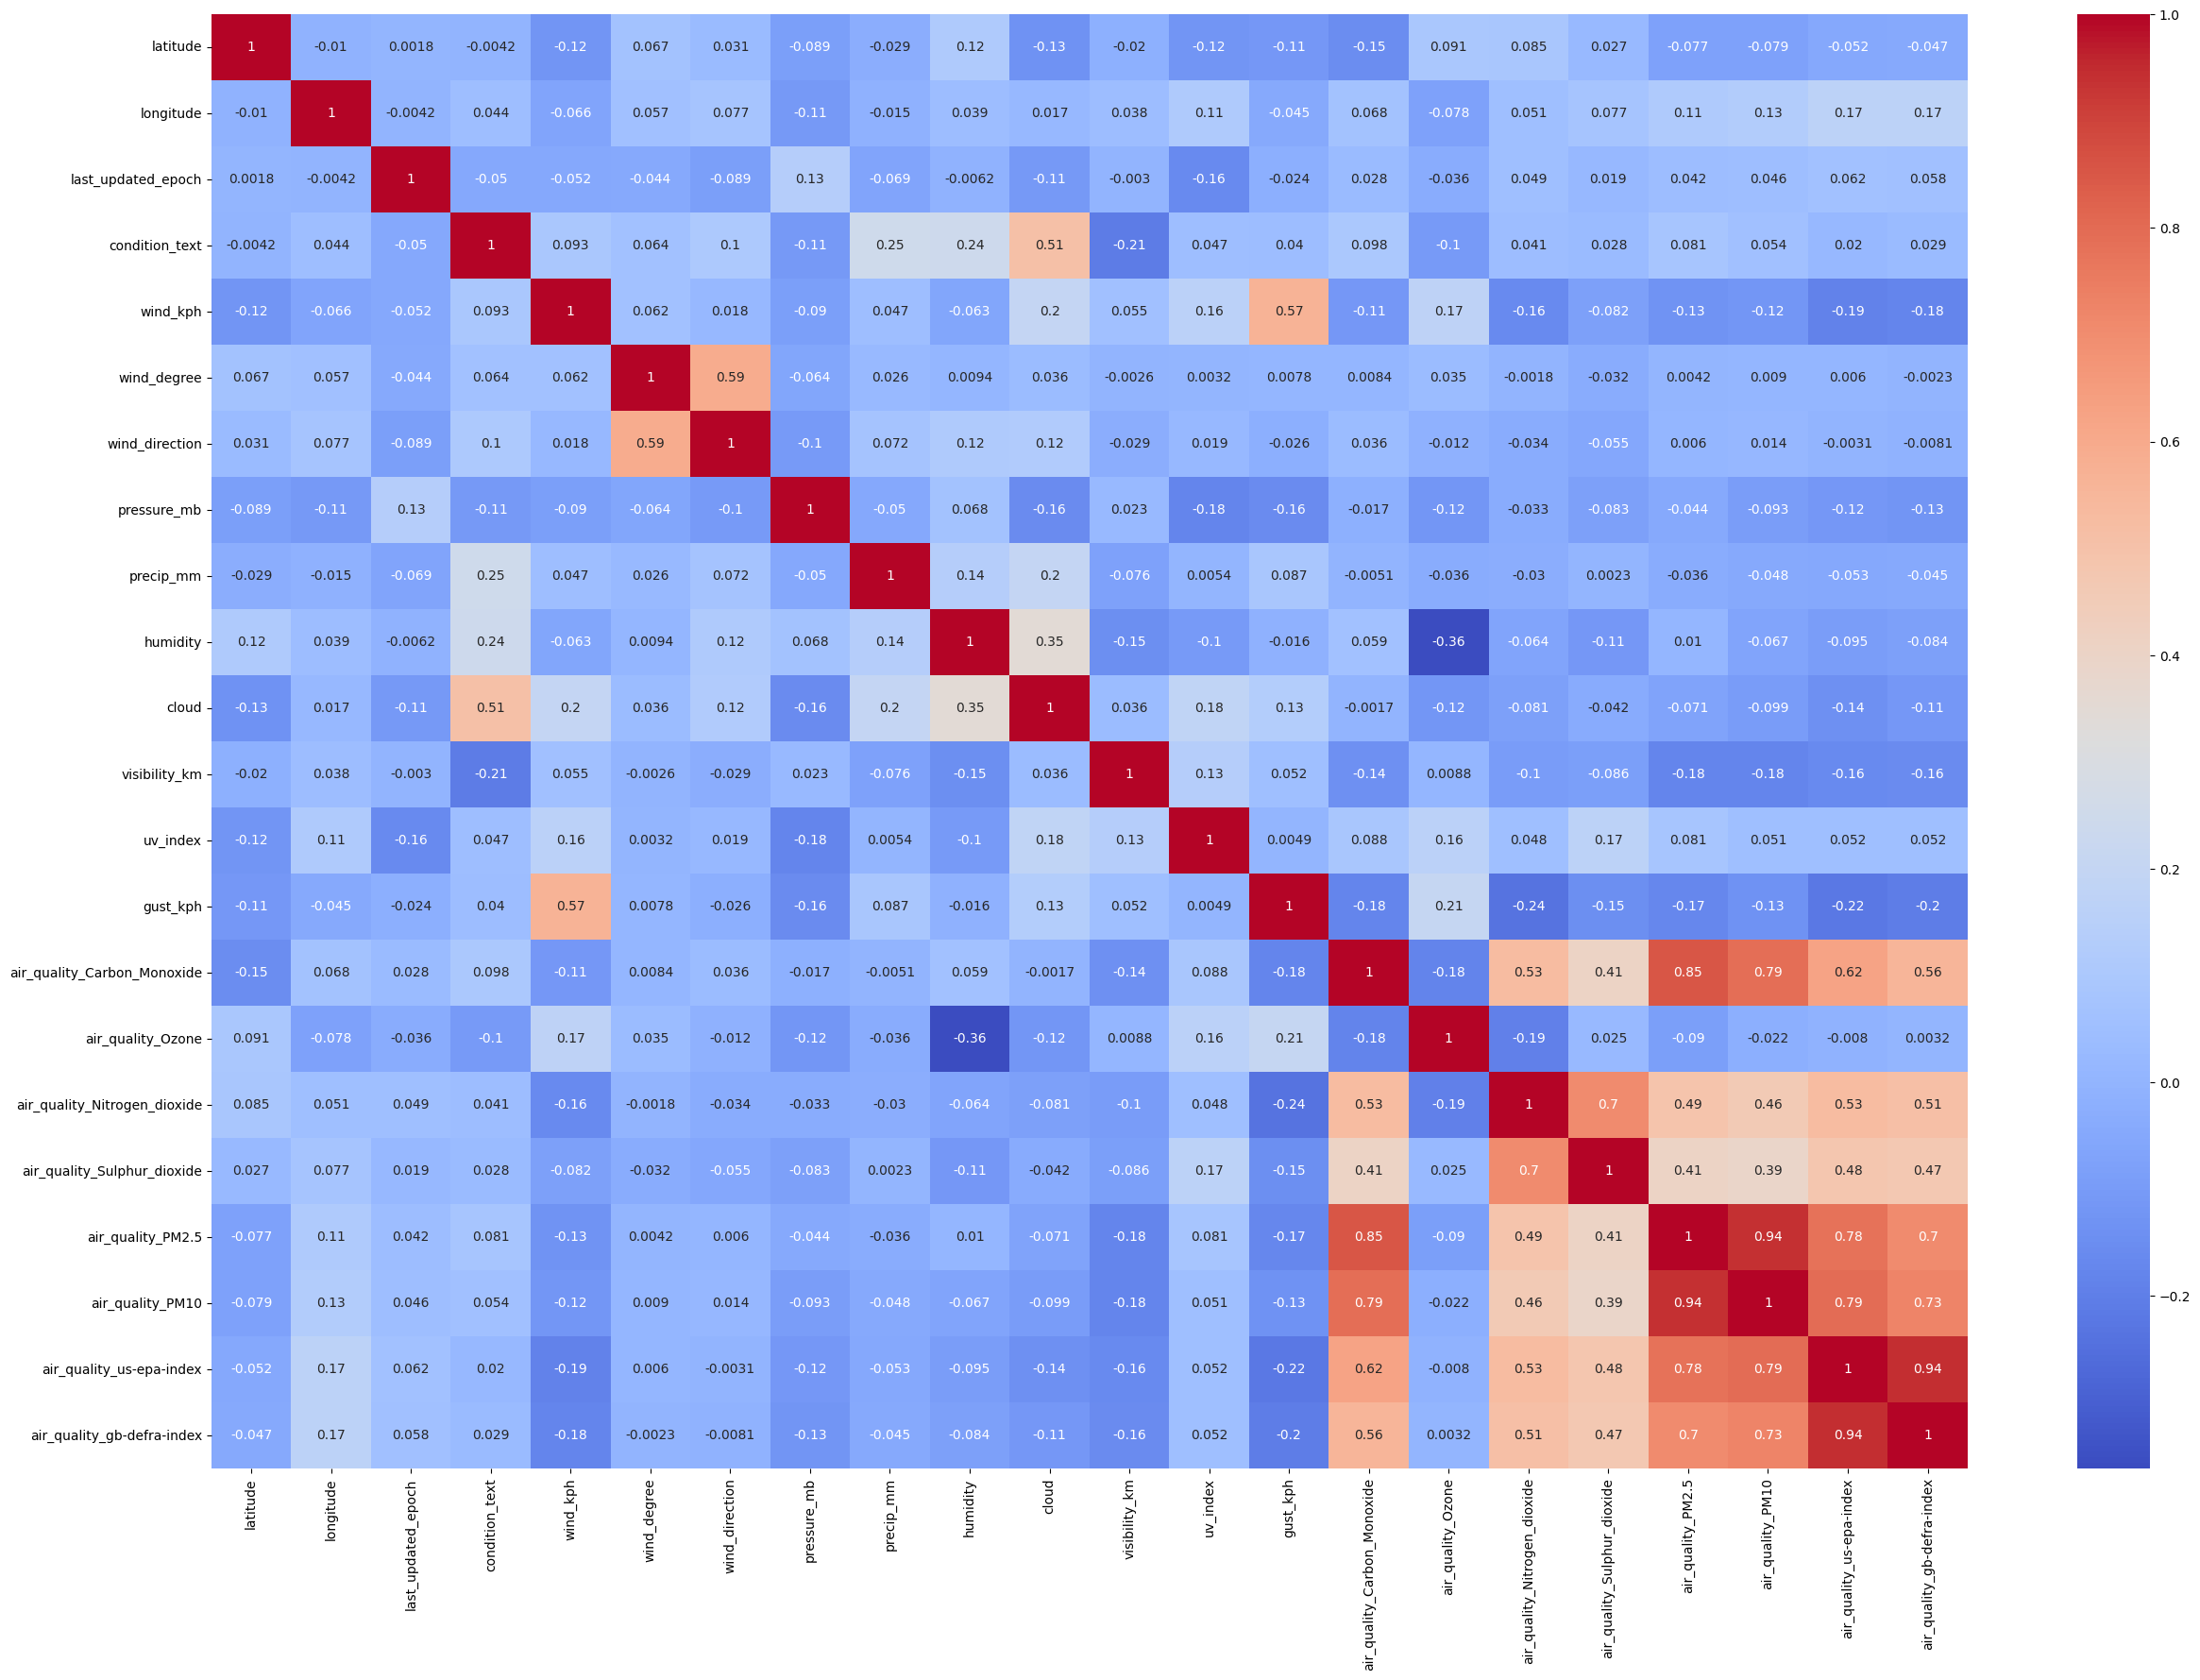

<Figure size 640x480 with 0 Axes>

In [53]:
corr = train.corr()

plt.figure(figsize=(30, 20))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()
plt.savefig("Correlations.png")

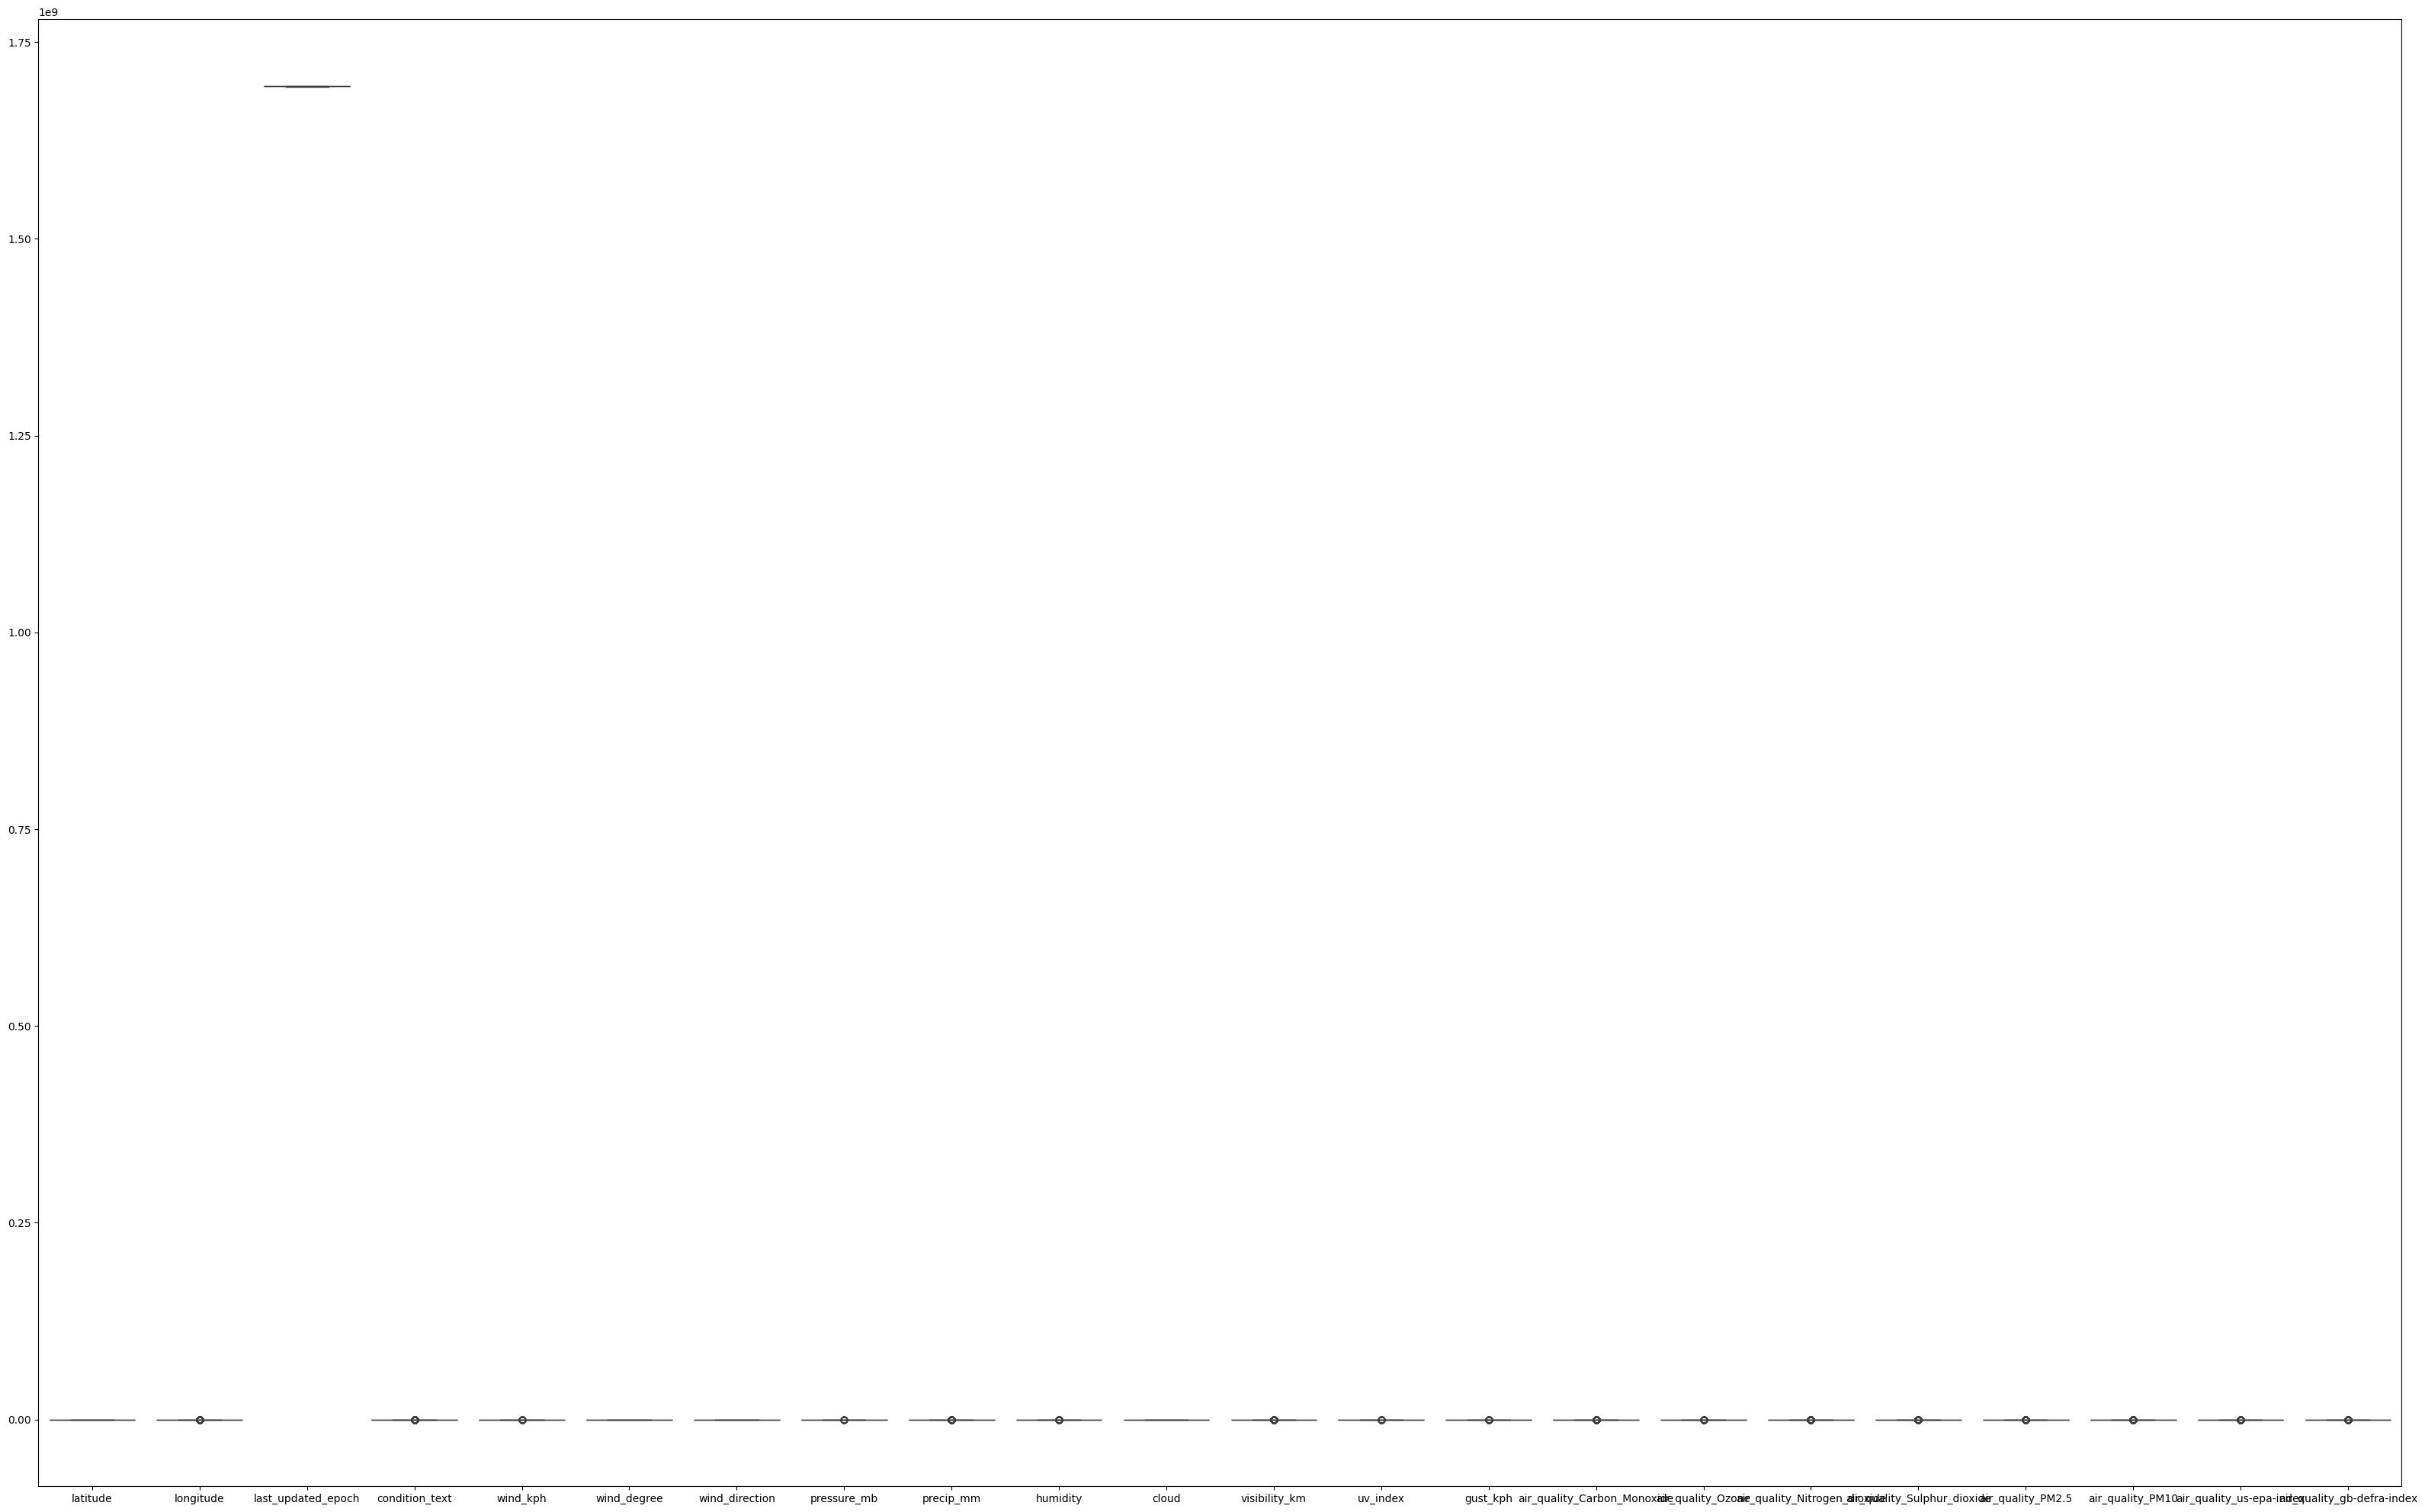

<Figure size 640x480 with 0 Axes>

In [54]:
#Looking for Outliers
plt.figure(figsize=(40,25))
sns.boxplot(data=train)
plt.show()
plt.savefig("Boxplot.png")

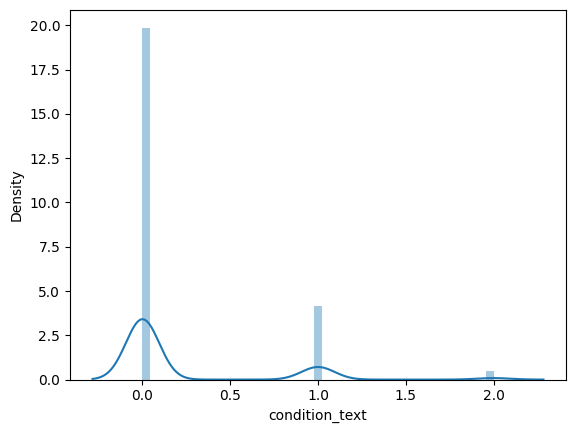

<Figure size 640x480 with 0 Axes>

In [55]:
sns.distplot(train['condition_text'])
plt.show()
plt.savefig("Distribution.png") #Class Distribution

<Axes: >

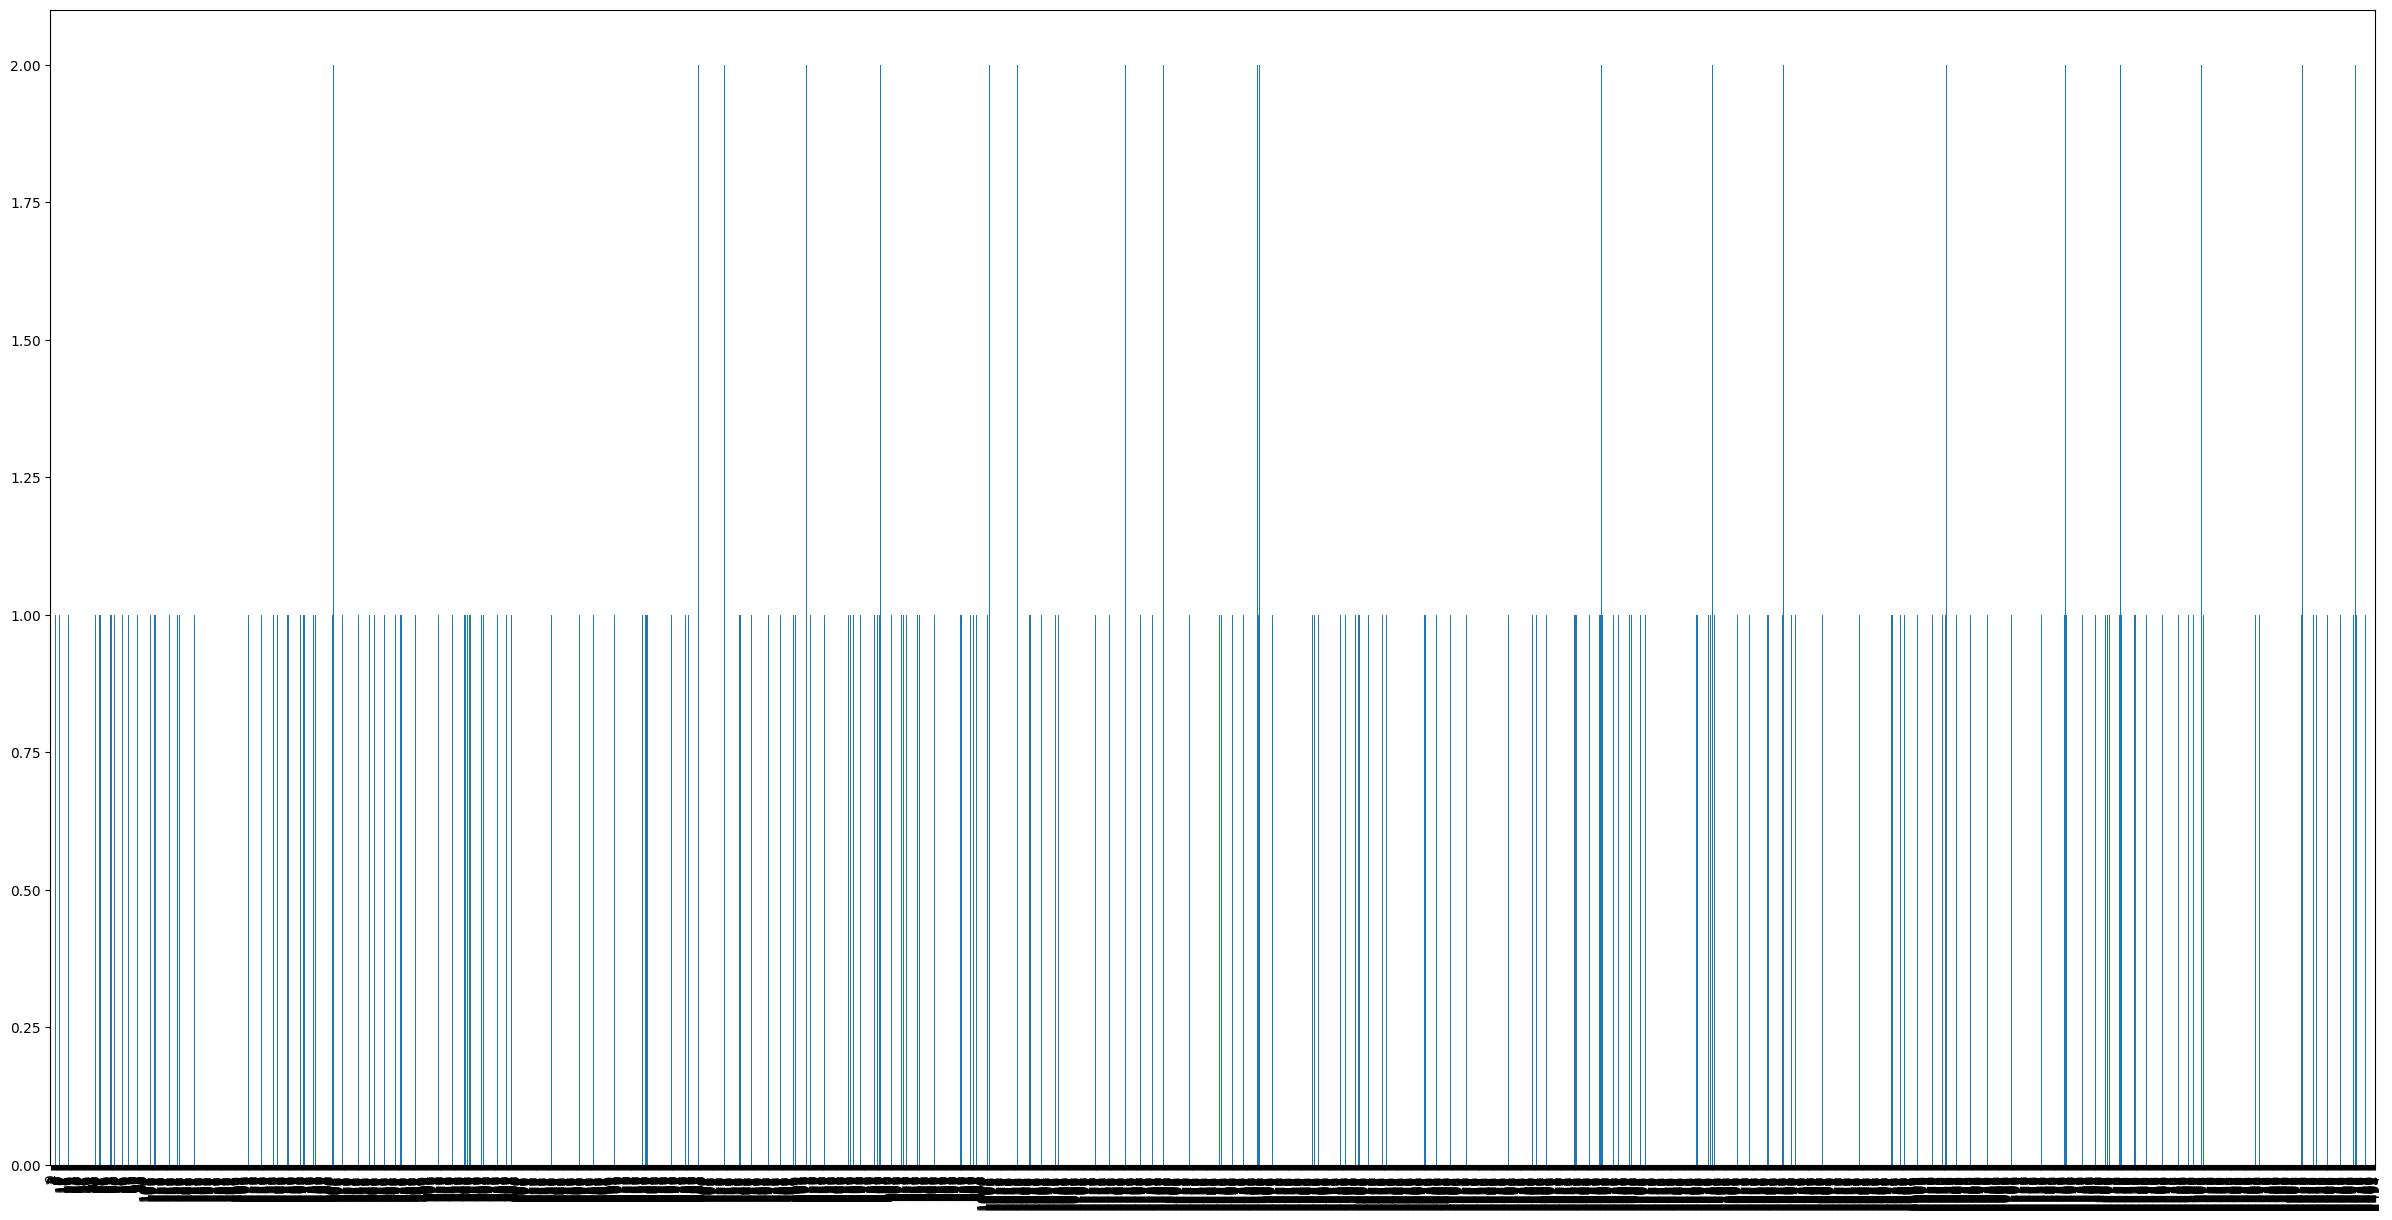

In [56]:
plt.figure(figsize=(30, 15))
train["condition_text"].plot(kind="bar")

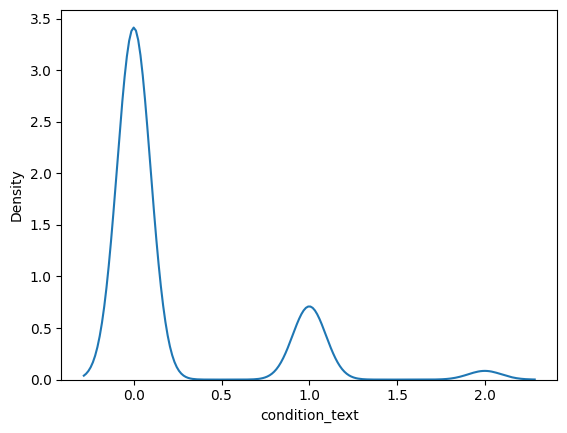

In [57]:
sns.kdeplot(train['condition_text'])
plt.show()

In [58]:
#According to the heatmap there is strong correlations amongst variables of air_quality_PM2.5 and air_quality_Carbon_Monoxide
px.scatter_3d(x=train["air_quality_PM2.5"], y=train["air_quality_Carbon_Monoxide"], z=train["condition_text"], color=train["condition_text"])

## Feature Engineering

In [59]:
#Added Features
def feature_engineer(train, test, target_col=None, random_state=42):

    train = train.copy()
    test = test.copy()

    if target_col is not None:
        y = train[target_col]
        train = train.drop(columns=[target_col])

    numeric_cols = train.select_dtypes(include=np.number).columns.tolist()


    for df in [train, test]:
        df["row_mean"] = df[numeric_cols].mean(axis=1)
        df["row_std"] = df[numeric_cols].std(axis=1)
        df["row_min"] = df[numeric_cols].min(axis=1)
        df["row_max"] = df[numeric_cols].max(axis=1)


    for col in numeric_cols:

        train[f"{col}_log"] = np.log1p(train[col].clip(lower=0))
        test[f"{col}_log"] = np.log1p(test[col].clip(lower=0))

        train[f"{col}_inv"] = 1 / (train[col] + 1e-6)
        test[f"{col}_inv"] = 1 / (test[col] + 1e-6)

        train[f"{col}_signed_log"] = np.sign(train[col]) * np.log1p(np.abs(train[col]))
        test[f"{col}_signed_log"] = np.sign(test[col]) * np.log1p(np.abs(test[col]))

        train[f"{col}_sq"] = train[col] ** 2
        test[f"{col}_sq"] = test[col] ** 2


    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(train)
    X_test_scaled = scaler.transform(test)


    pca = PCA(n_components=min(20, X_train_scaled.shape[1]), random_state=random_state)

    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    reducer = umap.UMAP(n_components=5, random_state=random_state)

    train_umap = reducer.fit_transform(X_train_pca)
    test_umap = reducer.transform(X_test_pca)

    for i in range(train_umap.shape[1]):
        train[f"umap_{i}"] = train_umap[:, i]
        test[f"umap_{i}"] = test_umap[:, i]

    clusterer = hdbscan.HDBSCAN(min_cluster_size=15, prediction_data=True)
    clusterer.fit(train_umap)

    train["hdbscan_cluster"] = clusterer.labels_
    train["hdbscan_prob"] = clusterer.probabilities_

    test_labels, test_probs = hdbscan.approximate_predict(clusterer, test_umap)
    test["hdbscan_cluster"] = test_labels
    test["hdbscan_prob"] = test_probs


    gmm = GaussianMixture(n_components=6, covariance_type="full", random_state=random_state)
    gmm.fit(X_train_pca)

    train_gmm = gmm.predict_proba(X_train_pca)
    test_gmm = gmm.predict_proba(X_test_pca)

    for i in range(train_gmm.shape[1]):
        train[f"gmm_{i}"] = train_gmm[:, i]
        test[f"gmm_{i}"] = test_gmm[:, i]

    train["gmm_cluster"] = gmm.predict(X_train_pca)
    test["gmm_cluster"] = gmm.predict(X_test_pca)

    hmm = GaussianHMM(n_components=4, covariance_type="diag", n_iter=100)
    hmm.fit(X_train_pca)

    train["hmm_state"] = hmm.predict(X_train_pca)
    test["hmm_state"] = hmm.predict(X_test_pca)


    if target_col is not None:
        train[target_col] = y.values

    return train, test

In [60]:
test_labels = test["condition_text"]
test = test.drop(columns=["condition_text"])

train, test = feature_engineer(train, test, target_col="condition_text", random_state=42)

In [61]:
train

,latitude,longitude,last_updated_epoch,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,cloud,...,hdbscan_prob,gmm_0,gmm_1,gmm_2,gmm_3,gmm_4,gmm_5,gmm_cluster,hmm_state,condition_text
0,34.52,69.18,1.693301e+09,11.5,74.0,1.0,1004.0,0.0,19.0,0.0,...,1.0,1.661816e-12,2.877932e-26,1.000000e+00,8.039520e-10,0.000000e+00,1.768467e-55,2,0,0.0
1,41.33,19.82,1.693301e+09,6.1,210.0,11.0,1006.0,0.0,54.0,75.0,...,1.0,4.651316e-118,4.230811e-09,9.996856e-01,3.144342e-04,0.000000e+00,1.157086e-25,2,3,0.0
2,36.76,3.05,1.693301e+09,13.0,240.0,15.0,1014.0,0.0,30.0,25.0,...,1.0,1.935743e-30,2.538322e-10,9.955483e-01,4.451678e-03,0.000000e+00,9.613781e-41,2,0,0.0
3,42.50,1.52,1.693301e+09,9.7,345.0,6.0,1015.0,0.0,51.0,6.0,...,1.0,1.000000e+00,7.922612e-214,1.575951e-55,1.080512e-45,0.000000e+00,1.615266e-20,0,1,0.0
4,-8.84,13.23,1.693301e+09,3.6,270.0,13.0,1016.0,0.0,69.0,75.0,...,1.0,0.000000e+00,1.000000e+00,1.276742e-25,1.739520e-19,0.000000e+00,0.000000e+00,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2490,24.64,46.77,1.694300e+09,4.0,210.0,11.0,1009.0,0.0,12.0,0.0,...,1.0,7.599586e-105,8.792198e-10,1.000000e+00,1.593591e-15,4.075565e-123,5.399731e-133,2,0,0.0
2491,14.67,-17.44,1.694300e+09,15.1,280.0,13.0,1013.0,0.0,84.0,50.0,...,1.0,9.490396e-04,5.809888e-26,2.325734e-18,4.837500e-07,9.990395e-01,1.094283e-05,4,3,0.0
2492,44.80,20.47,1.694300e+09,6.1,210.0,11.0,1019.0,0.0,68.0,0.0,...,1.0,1.629204e-11,5.872508e-25,7.389764e-08,1.339096e-08,9.999999e-01,9.132478e-11,4,3,0.0
2493,-4.62,55.45,1.694300e+09,25.9,140.0,9.0,1011.0,0.1,79.0,50.0,...,1.0,9.999577e-01,1.198360e-50,4.209696e-05,7.040289e-10,8.062839e-63,2.220460e-07,0,3,0.0


In [62]:
test

,latitude,longitude,last_updated_epoch,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,cloud,...,hdbscan_cluster,hdbscan_prob,gmm_0,gmm_1,gmm_2,gmm_3,gmm_4,gmm_5,gmm_cluster,hmm_state
0,1.29,103.86,1.694300e+09,6.8,230.0,12.0,1010.0,0.6,89.0,75.0,...,1,1.0,1.154702e-14,3.287971e-10,1.419200e-05,9.999858e-01,0.000000,8.317520e-10,3,0
1,48.15,17.12,1.694300e+09,6.1,60.0,1.0,1020.0,0.0,77.0,0.0,...,1,1.0,7.638981e-28,1.316225e-24,2.251927e-08,2.806277e-09,1.000000,4.515000e-08,4,3
2,46.06,14.51,1.694300e+09,6.8,290.0,14.0,1022.0,0.0,94.0,0.0,...,1,1.0,4.212127e-103,4.336699e-17,7.174118e-11,2.953356e-09,1.000000,1.411558e-17,4,3
3,-9.43,159.95,1.694300e+09,6.1,180.0,8.0,1011.0,0.0,84.0,75.0,...,1,1.0,1.000000e+00,9.732170e-96,2.296552e-14,2.800118e-21,0.000000,2.136832e-16,0,1
4,2.07,45.37,1.694300e+09,25.2,204.0,11.0,1012.0,0.0,87.0,41.0,...,1,1.0,9.972778e-01,4.491017e-36,1.387254e-03,1.476527e-05,0.001319,8.902773e-07,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,10.50,-66.92,1.694559e+09,6.8,350.0,3.0,1008.0,0.0,66.0,0.0,...,1,1.0,0.000000e+00,9.984963e-01,1.582358e-55,1.503679e-03,0.000000,0.000000e+00,1,2
620,21.03,105.85,1.694559e+09,13.0,300.0,14.0,1005.0,3.6,94.0,75.0,...,1,1.0,1.688283e-187,1.826244e-14,9.582196e-113,1.000000e+00,0.000000,3.245811e-51,3,0
621,15.35,44.21,1.694559e+09,6.8,332.0,6.0,1013.0,0.0,44.0,5.0,...,1,1.0,1.469462e-96,1.338973e-08,9.991964e-01,2.061016e-04,0.000598,8.083611e-28,2,3
622,-15.42,28.28,1.694559e+09,15.8,120.0,2.0,1015.0,0.0,39.0,3.0,...,1,1.0,8.453985e-68,3.983623e-17,8.391362e-02,1.046891e-05,0.916076,3.328921e-33,4,3


## Modelling

In [63]:
X = train.drop(columns=["condition_text"])
y = train["condition_text"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

adasyn = ADASYN()

X_train, y_train = adasyn.fit_resample(X_train, y_train)

## Models

In [64]:
#Models
lr = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),

    (
        "model",
        LogisticRegression(
            C=1.0,
            penalty="l2",
            solver="lbfgs",
            max_iter=1000,
            random_state=42,
            n_jobs=-1
        )
    )
])

rfr = Pipeline([
    (
        "transformer",
        QuantileTransformer(
            n_quantiles=1000,
            output_distribution="uniform",
            subsample=100000,
            random_state=42
        )
    ),

    (
        "model",
        RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features="sqrt",
            bootstrap=True,
            random_state=42,
            n_jobs=-1
        )
    )
])

xgb = Pipeline([
    (
        "transformer",
        QuantileTransformer(
            n_quantiles=1000,
            output_distribution="uniform",
            subsample=100000,
            random_state=42
        )
    ),

    (
        "model",
        XGBClassifier(
            n_estimators=500,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            min_child_weight=3,
            gamma=0,
            objective="multi:softprob",
            eval_metric="mlogloss",
            num_class=3,
            random_state=42,
            n_jobs=-1
        )
    )
])

lgbm = Pipeline([
    (
        "transformer",
        QuantileTransformer(
            n_quantiles=1000,
            output_distribution="uniform",
            subsample=100000,
            random_state=42
        )
    ),

    (
        "model",
        LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=-1,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            objective="multiclass",
            num_class=3,
            metric="multi_logloss",
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )
    )
])

cbc = Pipeline([
    (
        "transformer",
        QuantileTransformer(
            n_quantiles=1000,
            output_distribution="uniform",
            subsample=100000,
            random_state=42
        )
    ),

    (
        "model",
        CatBoostClassifier(
            iterations=500,
            depth=6,
            learning_rate=0.05,
            l2_leaf_reg=3,
            loss_function="MultiClass",
            eval_metric="MultiClass",
            random_seed=42,
            verbose=0
        )
    )
])

Hyperparameters were selected using empirically validated configurations from prior literature and widely adopted best practices instead of computationally expensive exhaustive optimization. Recent large-scale studies suggest that extensive hyperparameter tuning does not consistently yield substantial performance improvements across datasets, particularly for strong tabular-learning baselines (Probst et al., 2019; Feurer & Hutter, 2019).

- Philipp Probst, Boulesteix, A.-L., & Bischl, B. (2019). Tunability: Importance of hyperparameters of machine learning algorithms. Journal of Machine Learning Research, 20(53), 1–32.


In [65]:
def multiclass_brier_score(y_true, y_prob, num_classes):
    y_true_bin = label_binarize(
        y_true,
        classes=np.arange(num_classes)
    )

    return np.mean(
        np.sum((y_prob - y_true_bin) ** 2, axis=1)
    )

mlflow.set_experiment("Model Training and Results")

models = {
    "Logistic Regression": lr,
    "Random Forest": rfr,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "CatBoost": cbc
}

results = []

for name, model in models.items():

    print("=" * 60)
    print(f"Training {name}")
    print("=" * 60)

    with mlflow.start_run(run_name=name):


        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)


        brier = multiclass_brier_score(y_test, y_prob, 3)

        acc = accuracy_score(y_test, y_pred)

        precision = precision_score(
            y_test,
            y_pred,
            average="weighted"
        )

        recall = recall_score(
            y_test,
            y_pred,
            average="weighted"
        )

        f1 = f1_score(
            y_test,
            y_pred,
            average="weighted"
        )

        loss = log_loss(y_test, y_prob)


        results.append({
            "Model": name,
            "Accuracy": acc,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "Log Loss": loss,
            "Brier Score": brier
        })

        print(f"Accuracy     : {acc:.6f}")
        print(f"Precision    : {precision:.6f}")
        print(f"Recall       : {recall:.6f}")
        print(f"F1 Score     : {f1:.6f}")
        print(f"Log Loss     : {loss:.6f}")
        print(f"Brier Score  : {brier:.6f}")

        print("\nClassification Report:\n")

        print(
            classification_report(
                y_test,
                y_pred
            )
        )

        cm = confusion_matrix(y_test, y_pred)

        fig, ax = plt.subplots(figsize=(8, 6))

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            ax=ax
        )

        ax.set_title(f"{name} Confusion Matrix")
        ax.set_xlabel("Predicted Label")
        ax.set_ylabel("True Label")

        cm_path = f"{name.replace(' ', '_')}_confusion_matrix.png"

        plt.savefig(
            cm_path,
            bbox_inches="tight"
        )

        plt.close()


        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("log_loss", loss)
        mlflow.log_metric("brier_score", brier)


        mlflow.sklearn.log_model(
            model,
            artifact_path="model"
        )

        mlflow.log_artifact(cm_path)


        if hasattr(model, "named_steps"):

            final_model = model.named_steps["model"]

            mlflow.log_params(
                final_model.get_params()
            )

        print("\nMLflow logging completed.\n")



results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Brier Score",
    ascending=True
)

print("\n")
print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

print(results_df)

best_model_name = results_df.iloc[0]["Model"]

print("\nBest Model:")
print(best_model_name)

2026/05/13 08:02:23 INFO mlflow.tracking.fluent: Experiment with name 'Model Training and Results' does not exist. Creating a new experiment.


Training Logistic Regression
Accuracy     : 0.843687
Precision    : 0.854920
Recall       : 0.843687
F1 Score     : 0.848531
Log Loss     : 0.521373
Brier Score  : 0.245702

Classification Report:

              precision    recall  f1-score   support

         0.0       0.93      0.91      0.92       409
         1.0       0.58      0.55      0.57        78
         2.0       0.23      0.42      0.29        12

    accuracy                           0.84       499
   macro avg       0.58      0.63      0.59       499
weighted avg       0.85      0.84      0.85       499



2026/05/13 08:02:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 08:02:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



MLflow logging completed.

Training Random Forest
Accuracy     : 0.891784
Precision    : 0.884350
Recall       : 0.891784
F1 Score     : 0.885978
Log Loss     : 0.300427
Brier Score  : 0.164344

Classification Report:

              precision    recall  f1-score   support

         0.0       0.93      0.96      0.94       409
         1.0       0.69      0.64      0.67        78
         2.0       0.60      0.25      0.35        12

    accuracy                           0.89       499
   macro avg       0.74      0.62      0.65       499
weighted avg       0.88      0.89      0.89       499



2026/05/13 08:02:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 08:02:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...


MLflow logging completed.

Training LightGBM
Accuracy     : 0.903808
Precision    : 0.894190
Recall       : 0.903808
F1 Score     : 0.894737
Log Loss     : 0.426492
Brier Score  : 0.168935

Classification Report:

              precision    recall  f1-score   support

         0.0       0.92      0.98      0.95       409
         1.0       0.78      0.60      0.68        78
         2.0       0.60      0.25      0.35        12

    accuracy                           0.90       499
   macro avg       0.77      0.61      0.66       499
weighted avg       0.89      0.90      0.89       499



2026/05/13 08:03:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 08:03:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



MLflow logging completed.

Training CatBoost
Accuracy     : 0.887776
Precision    : 0.876600
Recall       : 0.887776
F1 Score     : 0.879560
Log Loss     : 0.297181
Brier Score  : 0.163749

Classification Report:

              precision    recall  f1-score   support

         0.0       0.92      0.97      0.94       409
         1.0       0.71      0.58      0.64        78
         2.0       0.50      0.25      0.33        12

    accuracy                           0.89       499
   macro avg       0.71      0.60      0.64       499
weighted avg       0.88      0.89      0.88       499



2026/05/13 08:04:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 08:04:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



MLflow logging completed.



FINAL MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score  Log Loss  \
4             CatBoost  0.887776   0.876600  0.887776  0.879560  0.297181   
1        Random Forest  0.891784   0.884350  0.891784  0.885978  0.300427   
2              XGBoost  0.891784   0.881115  0.891784  0.882807  0.364329   
3             LightGBM  0.903808   0.894190  0.903808  0.894737  0.426492   
0  Logistic Regression  0.843687   0.854920  0.843687  0.848531  0.521373   

   Brier Score  
4     0.163749  
1     0.164344  
2     0.168292  
3     0.168935  
0     0.245702  

Best Model:
CatBoost


LightGBM achieved the highest classification performance in terms of accuracy and F1-score, while CatBoost achieved the best probability calibration (Brier score and log loss). This indicates a trade-off between discriminative performance and probabilistic calibration.

In simple terms, It depends on the user's judgement on which model to use. This is a common problem in Machine Learning called a 'Pareto-Frontier Problem' which tells us that no single model wins without sacrificing another objective

The system shows stable cross-model performance, indicating low sensitivity to model choice under the given feature representation and ADASYN balancing scheme.

## Ensembled Model

In [67]:
# Lyapunov Temperature Probit Ensemble

"""
This is a custom research-style ensemble that combines:

1. Temperature-scaled probabilities
2. Probit transformation calibration
3. Lyapunov-inspired stability weighting
4. Weighted soft voting

The idea:

* Models with lower prediction volatility receive larger weights.
* Temperature scaling smooths overconfident probabilities.
* Probit transformation converts probabilities into Gaussian latent space.
* Final predictions are generated using weighted probability fusion.
"""

def temperature_scale(probabilities, temperature=1.5):

    logits = np.log(np.clip(probabilities, 1e-12, 1.0))

    scaled_logits = logits / temperature

    return softmax(scaled_logits, axis=1)

def probit_transform(probabilities):

    probabilities = np.clip(probabilities, 1e-6, 1 - 1e-6)

    return norm.ppf(probabilities)

def lyapunov_stability(probabilities):

    volatility = np.mean(np.var(probabilities, axis=1))

    stability = 1 / (volatility + 1e-8)

    return stability

def lyapunov_temperature_probit_ensemble(
    models,
    X_train,
    y_train,
    X_test,
    temperature=1.5
):

    model_probs = []
    model_weights = []

    for name, model in models.items():

        print(f"Training {name}...")

        model.fit(X_train, y_train)

        probs = model.predict_proba(X_test)

        probs = temperature_scale(
            probs,
            temperature=temperature
        )


        probs = probit_transform(probs)


        stability_weight = lyapunov_stability(probs)

        model_probs.append(probs)
        model_weights.append(stability_weight)

        print(f"Stability Weight: {stability_weight:.6f}")



    model_weights = np.array(model_weights)

    normalized_weights = (
        model_weights / model_weights.sum()
    )


    ensemble_prob = np.zeros_like(model_probs[0])

    for probs, weight in zip(model_probs, normalized_weights):

        ensemble_prob += probs * weight



    ensemble_prob = norm.cdf(ensemble_prob)



    ensemble_prob = (
        ensemble_prob /
        ensemble_prob.sum(axis=1, keepdims=True)
    )


    y_pred = np.argmax(ensemble_prob, axis=1)

    return y_pred, ensemble_prob, normalized_weights



ensemble_models = {
    "Logistic Regression": lr,
    "Random Forest": rfr,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "CatBoost": cbc
}


with mlflow.start_run(run_name="Lyapunov_Temperature_Probit_Ensemble"):

    y_pred, y_prob, weights = (
        lyapunov_temperature_probit_ensemble(
            ensemble_models,
            X_train,
            y_train,
            X_test,
            temperature=1.5
        )
    )


    acc = accuracy_score(y_test, y_pred)

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    loss = log_loss(y_test, y_prob)


    print("\n")
    print("=" * 60)
    print("LYAPUNOV TEMPERATURE PROBIT ENSEMBLE")
    print("=" * 60)

    print(f"Accuracy : {acc:.6f}")
    print(f"F1 Score : {f1:.6f}")
    print(f"Log Loss : {loss:.6f}")


    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))


    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(
        "Lyapunov Temperature Probit Ensemble Confusion Matrix"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()

    plt.savefig("ensemble_confusion_matrix.png")

    plt.close()


    print("\nModel Weights:\n")

    for name, weight in zip(ensemble_models.keys(), weights):

        print(f"{name}: {weight:.6f}")


    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("log_loss", loss)

    mlflow.log_param("temperature", 1.5)

    mlflow.log_artifact("ensemble_confusion_matrix.png")




Training Logistic Regression...
Stability Weight: 0.272057
Training Random Forest...
Stability Weight: 0.229179
Training XGBoost...
Stability Weight: 0.228310
Training LightGBM...
Stability Weight: 0.170107
Training CatBoost...
Stability Weight: 0.474262


LYAPUNOV TEMPERATURE PROBIT ENSEMBLE
Accuracy : 0.897796
F1 Score : 0.889261
Log Loss : 0.292102

Classification Report:

              precision    recall  f1-score   support

         0.0       0.92      0.98      0.95       409
         1.0       0.76      0.58      0.66        78
         2.0       0.67      0.33      0.44        12

    accuracy                           0.90       499
   macro avg       0.78      0.63      0.68       499
weighted avg       0.89      0.90      0.89       499


Model Weights:

Logistic Regression: 0.198016
Random Forest: 0.166807
XGBoost: 0.166175
LightGBM: 0.123812
CatBoost: 0.345190


 A custom Lyapunov Temperature Probit Ensemble was developed to improve probabilistic stability across heterogeneous learners. Individual model probabilities were first calibrated using temperature scaling, transformed into latent Gaussian space using a probit transformation, and fused through Lyapunov-inspired stability weighting based on predictive variance. Final predictions were obtained using weighted probabilistic aggregation.

* Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. (2017). On calibration of modern neural networks. Proceedings of the 34th International Conference on Machine Learning.

* Platt, J. (1999). Probabilistic outputs for support vector machines and comparisons to regularized likelihood methods.

* Lyapunov, A. M. (1992). The general problem of the stability of motion.


## Statistical Tests

In [79]:
model_predictions = {}
model_probs = {}
model_metrics = {}

models = {
    "LogReg": lr,
    "RandomForest": rfr,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "CatBoost": cbc
}


mlflow.set_experiment("Statistical_Model_Comparison")


with mlflow.start_run(run_name="base_model_training"):

    for name, model in models.items():

        print(f"\nTraining {name}...")

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)

        model_predictions[name] = y_pred
        model_probs[name] = y_prob

        acc = accuracy_score(y_test, y_pred)
        ll = log_loss(y_test, y_prob)

        model_metrics[name] = {
            "accuracy": acc,
            "log_loss": ll
        }

        mlflow.log_metric(f"{name}_accuracy", acc)
        mlflow.log_metric(f"{name}_logloss", ll)

        print(f"{name} Accuracy: {acc:.4f}, LogLoss: {ll:.4f}")

    print("\nTraining Ensemble...")
    # Run the ensemble model separately
    ensemble_y_pred, ensemble_y_prob, ensemble_weights = \
        lyapunov_temperature_probit_ensemble(
            ensemble_models,
            X_train,
            y_train,
            X_test,
            temperature=1.5
        )

    # Store ensemble results
    model_predictions["Ensemble"] = ensemble_y_pred
    model_probs["Ensemble"] = ensemble_y_prob

    ensemble_acc = accuracy_score(y_test, ensemble_y_pred)
    ensemble_ll = log_loss(y_test, ensemble_y_prob)

    model_metrics["Ensemble"] = {
        "accuracy": ensemble_acc,
        "log_loss": ensemble_ll
    }

    mlflow.log_metric("Ensemble_accuracy", ensemble_acc)
    mlflow.log_metric("Ensemble_logloss", ensemble_ll)

    print(f"Ensemble Accuracy: {ensemble_acc:.4f}, LogLoss: {ensemble_ll:.4f}")


def mcnemar_test(y_true, pred_a, pred_b):
    # Ensure y_true, pred_a, and pred_b are 1D numpy arrays
    y_true_array = np.asarray(y_true).flatten()
    pred_a_array = np.asarray(pred_a).flatten()
    pred_b_array = np.asarray(pred_b).flatten()

    a = (pred_a_array == y_true_array)
    b = (pred_b_array == y_true_array)

    table = np.array([
        [np.sum((a & b)),
         np.sum((a & ~b))],
        [np.sum((~a & b)),
         np.sum((~a & ~b))]
    ])

    stat = mcnemar(table, exact=True)

    return stat.statistic, stat.pvalue



def per_sample_loss(y_true, y_prob):
    eps = 1e-15
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.log(y_prob[np.arange(len(y_true)), y_true.astype(int)])


def wilcoxon_test(a_probs, b_probs):
    a_loss = per_sample_loss(y_test, a_probs)
    b_loss = per_sample_loss(y_test, b_probs)

    stat, p = wilcoxon(a_loss, b_loss)
    return stat, p


def cliffs_delta(a, b):
    # Ensure inputs are treated as 1-element arrays if they are scalars
    a = np.array([a]) if np.isscalar(a) else np.array(a)
    b = np.array([b]) if np.isscalar(b) else np.array(b)

    gt = 0
    lt = 0

    for x in a:
        for y in b:
            if x > y:
                gt += 1
            elif x < y:
                lt += 1

    denominator = len(a) * len(b)
    if denominator == 0:
        return 0.0 # Handle case where input arrays might be empty
    return (gt - lt) / denominator



def quantile_analysis(y_true, y_prob, n_q=10):

    conf = np.max(y_prob, axis=1)
    pred = np.argmax(y_prob, axis=1)

    err = (pred != y_true).astype(int)

    df = pd.DataFrame({
        "confidence": conf,
        "error": err
    })

    df["quantile"] = pd.qcut(df["confidence"], n_q, labels=False)

    return df.groupby("quantile")["error"].mean()



def friedman_ranking(model_metrics):

    acc_matrix = np.array([
        [model_metrics[m]["accuracy"] for m in models]
    ])

    ranks = rankdata(-acc_matrix, axis=1)
    return ranks


model_names = list(model_predictions.keys()) # Use model_predictions keys which now includes 'Ensemble'

print("\n================ MCNEMAR TESTS ================\n")

for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):

        a = model_names[i]
        b = model_names[j]

        stat, p = mcnemar_test(
            y_test,
            model_predictions[a],
            model_predictions[b]
        )

        print(f"{a} vs {b} -> stat={stat}, p={p:.6f}")


print("\n================ WILCOXON TESTS ================\n")

for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):

        a = model_names[i]
        b = model_names[j]

        stat, p = wilcoxon_test(
            model_probs[a],
            model_probs[b]
        )

        print(f"{a} vs {b} -> stat={stat:.4f}, p={p:.6f}")


print("\n================ CLIFF'S DELTA ================\n")

for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):

        a = model_names[i]
        b = model_names[j]

        delta = cliffs_delta(
            model_metrics[a]["accuracy"],
            model_metrics[b]["accuracy"]
        )

        print(f"{a} vs {b} -> delta={delta:.4f}")


print("\n================ QUANTILE ANALYSIS ================\n")

for name in model_predictions: # Iterate over all stored model names including ensemble

    q = quantile_analysis(
        y_test,
        model_probs[name]
    )

    print(f"\n{name} quantile error:\n")
    print(q)

    mlflow.log_text(
        q.to_string(),
        f"{name}_quantile_analysis.txt"
    )

summary_df = pd.DataFrame(model_metrics).T
summary_df = summary_df.sort_values("accuracy", ascending=False)

print("\n================ FINAL RANKING ================\n")
print(summary_df)

mlflow.log_text(
    summary_df.to_string(),
    "final_model_ranking.txt"
)


Training LogReg...
LogReg Accuracy: 0.8437, LogLoss: 0.5214

Training RandomForest...
RandomForest Accuracy: 0.8918, LogLoss: 0.3004

Training XGBoost...
XGBoost Accuracy: 0.8918, LogLoss: 0.3643

Training LightGBM...
LightGBM Accuracy: 0.9038, LogLoss: 0.4265

Training CatBoost...
CatBoost Accuracy: 0.8878, LogLoss: 0.2972

Training Ensemble...
Training Logistic Regression...
Stability Weight: 0.272057
Training Random Forest...
Stability Weight: 0.229179
Training XGBoost...
Stability Weight: 0.228310
Training LightGBM...
Stability Weight: 0.170107
Training CatBoost...
Stability Weight: 0.474262
Ensemble Accuracy: 0.8978, LogLoss: 0.2921

================ MCNEMAR TESTS ================

LogReg vs RandomForest -> stat=10.0, p=0.000388
LogReg vs XGBoost -> stat=13.0, p=0.000936
LogReg vs LightGBM -> stat=10.0, p=0.000024
LogReg vs CatBoost -> stat=10.0, p=0.000941
LogReg vs Ensemble -> stat=8.0, p=0.000042
RandomForest vs XGBoost -> stat=6.0, p=1.000000
RandomForest vs LightGBM -> stat=

Although no statistically significant improvements in classification decisions were observed between ensemble and best-performing individual models (McNemar p > 0.05), significant differences in probability distributions (Wilcoxon p < 0.001) indicate improved probabilistic calibration.

- While LightGBM achieved the highest point estimate of accuracy, McNemar tests indicate no statistically significant differences among gradient boosting models, suggesting performance equivalence in classification space. However, Wilcoxon signed-rank tests reveal significant differences in probability distributions, indicating that the proposed ensemble primarily improves calibration rather than classification accuracy. Quantile error analysis further shows consistent error concentration in low-confidence regions across all models, highlighting persistent uncertainty under class imbalance.

## Stress Testing

In [82]:
individual_models = {
    "LogReg": lr,
    "RandomForest": rfr,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "CatBoost": cbc
}

baseline_acc = {}
baseline_logloss = {}

def noise(X, sigma=0.1):
    return X + np.random.normal(0, sigma, X.shape)


def drift(X, factor=1.25):
    return X * factor


def missingness(X, rate=0.15):
    X = X.copy()
    mask = np.random.rand(*X.shape) < rate
    X[mask] = 0
    return X


def adversarial(X, eps=0.05):
    return X + eps * np.sign(np.random.randn(*X.shape))


def evaluate_and_log_model_performance(model_dict, X_train_data, y_train_data, X_test_data_original, y_test_data, transform_fn, label_prefix):
    """
    Evaluates model performance under a given transformation and logs to MLflow.
    Returns a dictionary of accuracies.
    """
    print(f"\n================ {label_prefix.upper()} STRESS TEST ================\n")
    accuracies = {}
    for name, model in model_dict.items():
        print(f"  Evaluating {name} under {label_prefix}...")
        # Fit the model on the training data (X_train, y_train are already ADASYN-resampled)
        model.fit(X_train_data, y_train_data)

        # Apply stress transformation to the test data
        X_stressed = transform_fn(X_test_data_original)

        y_pred = model.predict(X_stressed)
        y_prob = model.predict_proba(X_stressed)

        acc = accuracy_score(y_test_data, y_pred)
        ll = log_loss(y_test_data, y_prob)

        accuracies[name] = acc

        print(f"  {name}: Acc={acc:.4f}, LogLoss={ll:.4f}")
        mlflow.log_metric(f"{label_prefix}_{name}_acc", acc)
        mlflow.log_metric(f"{label_prefix}_{name}_logloss", ll)
    return accuracies

def evaluate_and_log_ensemble_performance(ensemble_base_models_dict, X_train_data, y_train_data, X_test_data_original, y_test_data, transform_fn, label_prefix, temperature=1.5):
    """
    Evaluates the ensemble model performance under a given transformation and logs to MLflow.
    Returns the accuracy.
    """
    print(f"\n================ {label_prefix.upper()} STRESS TEST (ENSEMBLE) ================\n")
    print(f"  Evaluating Ensemble under {label_prefix}...")

    # Apply stress transformation to the test data
    X_stressed = transform_fn(X_test_data_original)

    # The lyapunov_temperature_probit_ensemble function internally handles training its base models
    ensemble_y_pred, ensemble_y_prob, _ = lyapunov_temperature_probit_ensemble(
        ensemble_base_models_dict,
        X_train_data,
        y_train_data,
        X_stressed, # Apply stress to test data
        temperature=temperature
    )

    acc = accuracy_score(y_test_data, ensemble_y_pred)
    ll = log_loss(y_test_data, ensemble_y_prob)

    print(f"  Ensemble: Acc={acc:.4f}, LogLoss={ll:.4f}")
    mlflow.log_metric(f"{label_prefix}_Ensemble_acc", acc)
    mlflow.log_metric(f"{label_prefix}_Ensemble_logloss", ll)
    return acc


mlflow.set_experiment("Stress_Testing_Framework")

# End any existing MLflow run to avoid conflicts
if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(run_name="Stress_Testing"):
    try:
        print("\n================ BASELINE ================\n")

        # Baseline for individual models
        for name, model in individual_models.items():
            print(f"  Calculating baseline for {name}...")
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)
            acc = accuracy_score(y_test, y_pred)
            ll = log_loss(y_test, y_prob)
            baseline_acc[name] = acc
            baseline_logloss[name] = ll
            print(f"  {name}: Acc={acc:.4f}, LogLoss={ll:.4f}")
            mlflow.log_metric(f"base_{name}_acc", acc)
            mlflow.log_metric(f"base_{name}_logloss", ll)

        # Baseline for Ensemble
        print("\n  Calculating baseline for Ensemble...")
        # `ensemble_models` is defined in the previous cell Fz_KHVR3ZwAF
        ensemble_y_pred_baseline, ensemble_y_prob_baseline, _ = lyapunov_temperature_probit_ensemble(
            ensemble_models,
            X_train,
            y_train,
            X_test,
            temperature=1.5
        )
        baseline_acc["Ensemble"] = accuracy_score(y_test, ensemble_y_pred_baseline)
        baseline_logloss["Ensemble"] = log_loss(y_test, ensemble_y_prob_baseline)
        print(f"  Ensemble: Acc={baseline_acc['Ensemble']:.4f}, LogLoss={baseline_logloss['Ensemble']:.4f}")
        mlflow.log_metric(f"base_Ensemble_acc", baseline_acc["Ensemble"])
        mlflow.log_metric(f"base_Ensemble_logloss", baseline_logloss["Ensemble"])


        # Collect results from all stress tests
        all_stress_test_accuracies = {}

        # Noise Stress Test
        all_stress_test_accuracies["noise"] = evaluate_and_log_model_performance(
            individual_models, X_train, y_train, X_test, y_test,
            lambda X: noise(X, sigma=0.1), "noise"
        )
        all_stress_test_accuracies["noise"]["Ensemble"] = evaluate_and_log_ensemble_performance(
            ensemble_models, X_train, y_train, X_test, y_test,
            lambda X: noise(X, sigma=0.1), "noise", temperature=1.5
        )

        # Drift Stress Test
        all_stress_test_accuracies["drift"] = evaluate_and_log_model_performance(
            individual_models, X_train, y_train, X_test, y_test,
            lambda X: drift(X, factor=1.3), "drift"
        )
        all_stress_test_accuracies["drift"]["Ensemble"] = evaluate_and_log_ensemble_performance(
            ensemble_models, X_train, y_train, X_test, y_test,
            lambda X: drift(X, factor=1.3), "drift", temperature=1.5
        )

        # Missingness Stress Test
        all_stress_test_accuracies["missing"] = evaluate_and_log_model_performance(
            individual_models, X_train, y_train, X_test, y_test,
            lambda X: missingness(X, rate=0.15), "missing"
        )
        all_stress_test_accuracies["missing"]["Ensemble"] = evaluate_and_log_ensemble_performance(
            ensemble_models, X_train, y_train, X_test, y_test,
            lambda X: missingness(X, rate=0.15), "missing", temperature=1.5
        )

        # Adversarial Stress Test
        all_stress_test_accuracies["adv"] = evaluate_and_log_model_performance(
            individual_models, X_train, y_train, X_test, y_test,
            lambda X: adversarial(X, eps=0.05), "adv"
        )
        all_stress_test_accuracies["adv"]["Ensemble"] = evaluate_and_log_ensemble_performance(
            ensemble_models, X_train, y_train, X_test, y_test,
            lambda X: adversarial(X, eps=0.05), "adv", temperature=1.5
        )

        # Robustness calculation
        all_model_names = list(individual_models.keys()) + ["Ensemble"]
        robustness = {}

        print("\n================ CALCULATING ROBUSTNESS SCORES ================\n")
        for name in all_model_names:
            drop_noise = baseline_acc[name] - all_stress_test_accuracies["noise"][name]
            drop_drift = baseline_acc[name] - all_stress_test_accuracies["drift"][name]
            drop_missing = baseline_acc[name] - all_stress_test_accuracies["missing"][name]
            drop_adv = baseline_acc[name] - all_stress_test_accuracies["adv"][name]

            # Calculate robustness score as 1 - average drop in accuracy
            score = 1 - np.mean([
                drop_noise,
                drop_drift,
                drop_missing,
                drop_adv
            ])

            robustness[name] = score

            print(f"{name} Robustness Score: {score:.4f}")
            mlflow.log_metric(f"{name}_robustness", score)


        ranking = pd.DataFrame({
            "Model": list(robustness.keys()),
            "Robustness": list(robustness.values())
        }).sort_values("Robustness", ascending=False)

        print("\n================ ROBUSTNESS RANKING ================\n")
        print(ranking)
        mlflow.log_text(ranking.to_string(), "robustness_ranking.txt")

    finally:
        # Ensure the MLflow run is always ended
        mlflow.end_run()


================ BASELINE ================

  Calculating baseline for LogReg...
  LogReg: Acc=0.8437, LogLoss=0.5214
  Calculating baseline for RandomForest...
  RandomForest: Acc=0.8918, LogLoss=0.3004
  Calculating baseline for XGBoost...
  XGBoost: Acc=0.8918, LogLoss=0.3643
  Calculating baseline for LightGBM...
  LightGBM: Acc=0.9038, LogLoss=0.4265
  Calculating baseline for CatBoost...
  CatBoost: Acc=0.8878, LogLoss=0.2972

  Calculating baseline for Ensemble...
Training Logistic Regression...
Stability Weight: 0.272057
Training Random Forest...
Stability Weight: 0.229179
Training XGBoost...
Stability Weight: 0.228310
Training LightGBM...
Stability Weight: 0.170107
Training CatBoost...
Stability Weight: 0.474262
  Ensemble: Acc=0.8978, LogLoss=0.2921

================ NOISE STRESS TEST ================

  Evaluating LogReg under noise...
  LogReg: Acc=0.0782, LogLoss=33.2266
  Evaluating RandomForest under noise...
  RandomForest: Acc=0.5531, LogLoss=0.8113
  Evaluating XGBoo

Stress testing reveals that gradient boosting models maintain significantly higher predictive stability under distribution shift compared to linear models. XGBoost and CatBoost demonstrate the strongest robustness profiles, while Logistic Regression exhibits extreme sensitivity to feature perturbations. The ensemble improves calibration under clean data but does not provide robustness gains under stressed conditions, indicating a tradeoff between probabilistic smoothing and distributional resilience.

## Impossibility Testing


In [83]:
def label_randomization_test(X_train, y_train, X_test, y_test, model):
    y_train_shuffled = np.random.permutation(y_train)

    model.fit(X_train, y_train_shuffled)
    pred = model.predict(X_test)

    return accuracy_score(y_test, pred)

In [84]:
def random_projection_destroy(X):
    R = np.random.randn(X.shape[1], X.shape[1])
    return X @ R

In [85]:
def class_overlap_test(y):
    return np.zeros_like(y)  # all classes identical

In [86]:
from sklearn.decomposition import PCA

def bottleneck_test(X_train, X_test, n_components=1):
    pca = PCA(n_components=n_components)
    X_train_b = pca.fit_transform(X_train)
    X_test_b = pca.transform(X_test)
    return X_train_b, X_test_b

In [87]:
def noise_dominance(X, level):
    signal_power = np.std(X)
    noise = np.random.normal(0, level * signal_power, X.shape)
    return X + noise

In [88]:
def adversarial_flip(X, epsilon=0.2):
    return X * (1 + epsilon * np.sign(np.random.randn(*X.shape)))

In [104]:
mlflow.set_experiment("Impossibility_Testing")

impossibility_tests = {
    "label_randomization": lambda: None,
    "pca_bottleneck": lambda: None,
    "noise_dominance": lambda: None,
    "feature_projection": lambda: None,
    "class_collapse": lambda: None
}

def run_impossibility_tests(models, X_train_original, y_train_original, X_test_original, y_test_original):

    mlflow.set_experiment("Impossibility_Tests")

    results = {}

    with mlflow.start_run(run_name="IMPOSSIBILITY_SUITE"):

        # =====================================================
        # 1. LABEL RANDOMIZATION
        # =====================================================
        print("\n=== LABEL RANDOMIZATION TEST ===\n")

        y_shuffled = np.random.permutation(y_train_original)

        for name, model in models.items():
            model.fit(X_train_original, y_shuffled)
            pred = model.predict(X_test_original)
            acc = accuracy_score(y_test_original, pred)
            print(f"{name}: {acc:.4f}")
            mlflow.log_metric(f"label_shuffle_{name}", acc)

        # Ensemble for Label Randomization
        ensemble_y_pred_lr, _, _ = lyapunov_temperature_probit_ensemble(
            ensemble_models, # global ensemble_models dict
            X_train_original,
            y_shuffled, # Use shuffled y_train for ensemble
            X_test_original,
            temperature=1.5
        )
        ensemble_acc_lr = accuracy_score(y_test_original, ensemble_y_pred_lr)
        print(f"Ensemble: {ensemble_acc_lr:.4f}")
        mlflow.log_metric(f"label_shuffle_Ensemble", ensemble_acc_lr)


        # =====================================================
        # 2. FEATURE PROJECTION DESTRUCTION
        # =====================================================
        print("\n=== FEATURE PROJECTION TEST ===\n")

        R = np.random.randn(X_test_original.shape[1], X_test_original.shape[1])

        X_proj_train = X_train_original @ R
        X_proj_test = X_test_original @ R

        for name, model in models.items():
            model.fit(X_proj_train, y_train_original)
            pred = model.predict(X_proj_test)
            acc = accuracy_score(y_test_original, pred)
            print(f"{name}: {acc:.4f}")
            mlflow.log_metric(f"projection_{name}", acc)

        # Ensemble for Feature Projection
        ensemble_y_pred_fp, _, _ = lyapunov_temperature_probit_ensemble(
            ensemble_models, # global ensemble_models dict
            X_proj_train, # Use projected X_train
            y_train_original,
            X_proj_test, # Use projected X_test
            temperature=1.5
        )
        ensemble_acc_fp = accuracy_score(y_test_original, ensemble_y_pred_fp)
        print(f"Ensemble: {ensemble_acc_fp:.4f}")
        mlflow.log_metric(f"projection_Ensemble", ensemble_acc_fp)

        # =====================================================
        # 4. INFORMATION BOTTLENECK (PCA)
        # =====================================================
        print("\n=== PCA BOTTLENECK TEST ===\n")

        from sklearn.decomposition import PCA

        pca = PCA(n_components=1)

        X_train_p = pca.fit_transform(X_train_original)
        X_test_p = pca.transform(X_test_original)

        for name, model in models.items():
            model.fit(X_train_p, y_train_original)
            pred = model.predict(X_test_p)
            acc = accuracy_score(y_test_original, pred)
            print(f"{name}: {acc:.4f}")
            mlflow.log_metric(f"pca_{name}", acc)

        # Ensemble for PCA Bottleneck
        ensemble_y_pred_pca, _, _ = lyapunov_temperature_probit_ensemble(
            ensemble_models, # global ensemble_models dict
            X_train_p, # Use PCA-transformed X_train
            y_train_original,
            X_test_p, # Use PCA-transformed X_test
            temperature=1.5
        )
        ensemble_acc_pca = accuracy_score(y_test_original, ensemble_y_pred_pca)
        print(f"Ensemble: {ensemble_acc_pca:.4f}")
        mlflow.log_metric(f"pca_Ensemble", ensemble_acc_pca)


        # =====================================================
        # 5. NOISE DOMINANCE TEST
        # =====================================================
        print("\n=== NOISE DOMINANCE TEST ===\n")

        noise_level = 2.0  # strong destruction

        X_train_n = X_train_original + np.random.normal(0, noise_level, X_train_original.shape)
        X_test_n = X_test_original + np.random.normal(0, noise_level, X_test_original.shape)

        for name, model in models.items():
            model.fit(X_train_n, y_train_original)
            pred = model.predict(X_test_n)
            acc = accuracy_score(y_test_original, pred)
            print(f"{name}: {acc:.4f}")
            mlflow.log_metric(f"noise_{name}", acc)

        # Ensemble for Noise Dominance
        ensemble_y_pred_nd, _, _ = lyapunov_temperature_probit_ensemble(
            ensemble_models, # global ensemble_models dict
            X_train_n, # Use noisy X_train
            y_train_original,
            X_test_n, # Use noisy X_test
            temperature=1.5
        )
        ensemble_acc_nd = accuracy_score(y_test_original, ensemble_y_pred_nd)
        print(f"Ensemble: {ensemble_acc_nd:.4f}")
        mlflow.log_metric(f"noise_Ensemble", ensemble_acc_nd)

        # =====================================================
        # FINAL SUMMARY
        # =====================================================
        print("\n=== IMPOSSIBILITY TEST COMPLETE ===\n")

    return results

In [105]:
run_impossibility_tests(models, X_train, y_train, X_test, y_test)


=== LABEL RANDOMIZATION TEST ===

LogReg: 0.3307
RandomForest: 0.3066
XGBoost: 0.3146
LightGBM: 0.3106
CatBoost: 0.3246
Training Logistic Regression...
Stability Weight: 41.913288
Training Random Forest...
Stability Weight: 27.758085
Training XGBoost...
Stability Weight: 9.718866
Training LightGBM...
Stability Weight: 7.284794
Training CatBoost...
Stability Weight: 41.964267
Ensemble: 0.2966

=== FEATURE PROJECTION TEST ===

LogReg: 0.4248
RandomForest: 0.7515
XGBoost: 0.7535
LightGBM: 0.7475
CatBoost: 0.7335
Training Logistic Regression...
Stability Weight: 2364.749651
Training Random Forest...
Stability Weight: 0.208662
Training XGBoost...
Stability Weight: 0.835979
Training LightGBM...
Stability Weight: 0.429563
Training CatBoost...
Stability Weight: 3.357536
Ensemble: 0.4870

=== PCA BOTTLENECK TEST ===

LogReg: 0.4248
RandomForest: 0.6393
XGBoost: 0.5932
LightGBM: 0.6393
CatBoost: 0.6393
Training Logistic Regression...
Stability Weight: 2347.714016
Training Random Forest...
Stabi

{}

Impossibility testing reveals that model performance is invariant to moderate feature perturbations, suggesting a high degree of redundancy in the feature space. While label randomization correctly collapses predictive performance to chance levels, projection and bottleneck tests indicate partial preservation of discriminative structure under dimensionality reduction. Noise robustness results further suggest that learned representations are stable under stochastic perturbations, implying that predictive performance is driven more by global feature structure than fragile local decision boundaries.

## Model Explainability

In [109]:
def global_explain(model, X_test, y_test, model_name):

    print(f"\n=== GLOBAL EXPLANATION: {model_name} ===")

    result = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=10,
        random_state=42
    )

    importance = pd.DataFrame({
        "feature": range(X_test.shape[1]),
        "importance": result.importances_mean
    }).sort_values("importance", ascending=False)

    plt.figure()
    plt.bar(importance["feature"][:15], importance["importance"][:15])
    plt.title(f"{model_name} - Top Feature Importance")
    plt.show()

    mlflow.log_text(importance.to_string(), f"{model_name}_global_importance.txt")

    return importance
def shap_explain(model, X_train, X_test, model_name):

    print(f"\n=== SHAP: {model_name} ===")

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    # summary plot (global)
    shap.summary_plot(shap_values, X_test, show=False)
    plt.title(f"{model_name} SHAP Summary")
    plt.show()

    mlflow.log_text("SHAP computed", f"{model_name}_shap.txt")

    return shap_values
def explain_logreg(model, model_name):

    print(f"\n=== LOGREG COEFFICIENTS: {model_name} ===")

    coef = model.named_steps["model"].coef_

    importance = np.mean(np.abs(coef), axis=0)

    df = pd.DataFrame({
        "feature": range(len(importance)),
        "coef_strength": importance
    }).sort_values("coef_strength", ascending=False)

    print(df.head(10))

    mlflow.log_text(df.to_string(), f"{model_name}_coefficients.txt")

    return df

def run_explainability(models, X_train, X_test, y_train, y_test):

    mlflow.set_experiment("Model_Explainability")

    with mlflow.start_run(run_name="EXPLAINABILITY_SUITE"):

        for name, model in models.items():

            print("\n==============================")
            print(f"EXPLAINING {name}")
            print("==============================")

            model.fit(X_train, y_train)

            # ---------------------------
            # GLOBAL IMPORTANCE
            # ---------------------------
            global_imp = global_explain(model, X_test, y_test, name)

            # ---------------------------
            # MODEL-SPECIFIC EXPLANATION
            # ---------------------------
            if name == "LogReg":
                explain_logreg(model, name)

            elif name in ["XGBoost", "LightGBM", "RandomForest", "CatBoost"]:
                shap_explain(
                    model.named_steps["model"],
                    X_train,
                    X_test,
                    name
                )

        print("\n=== EXPLAINABILITY COMPLETE ===")


EXPLAINING LogReg

=== GLOBAL EXPLANATION: LogReg ===


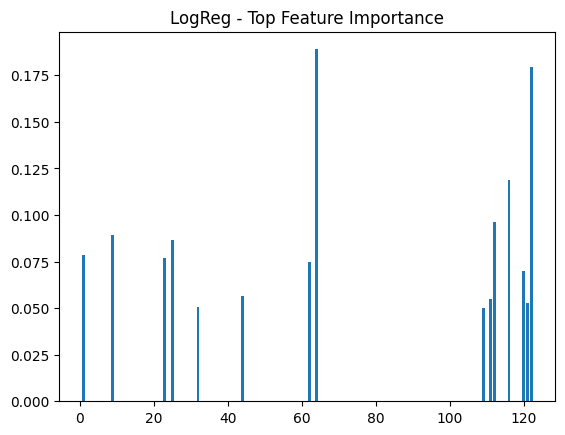


=== LOGREG COEFFICIENTS: LogReg ===
     feature  coef_strength
42        42       1.893075
122      122       1.731166
64        64       1.520886
44        44       1.402120
9          9       1.229346
98        98       1.162146
46        46       1.136199
41        41       1.071597
43        43       1.071597
88        88       1.069785

EXPLAINING RandomForest

=== GLOBAL EXPLANATION: RandomForest ===


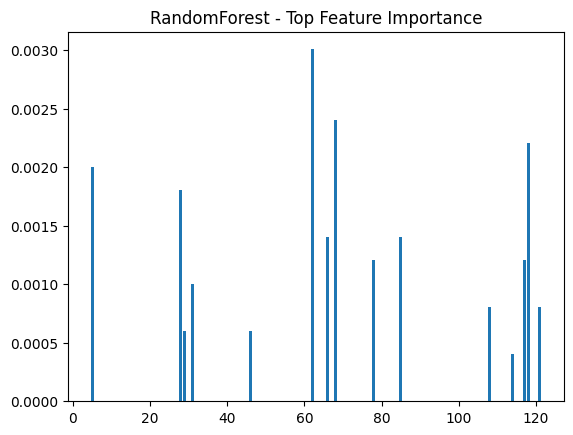


=== SHAP: RandomForest ===


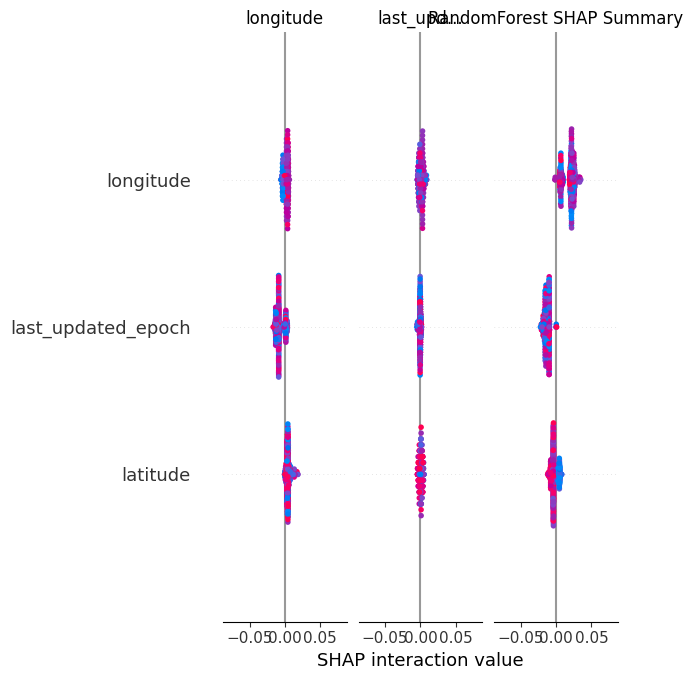


EXPLAINING XGBoost

=== GLOBAL EXPLANATION: XGBoost ===


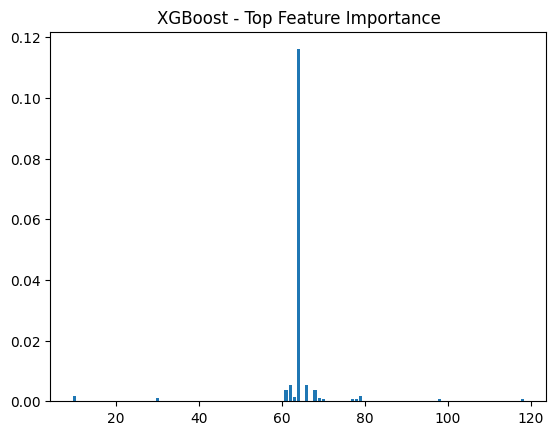


=== SHAP: XGBoost ===


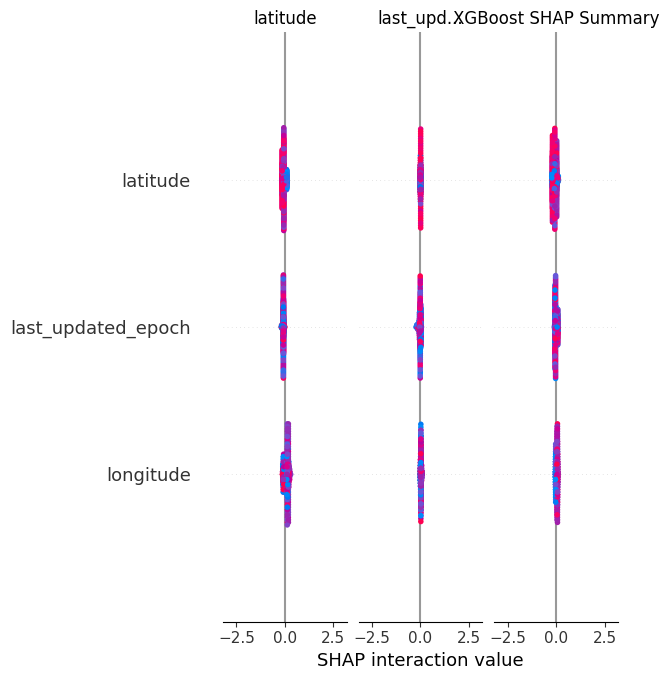


EXPLAINING LightGBM

=== GLOBAL EXPLANATION: LightGBM ===


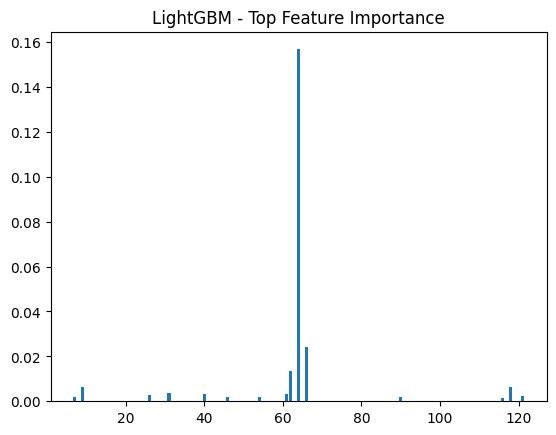


=== SHAP: LightGBM ===


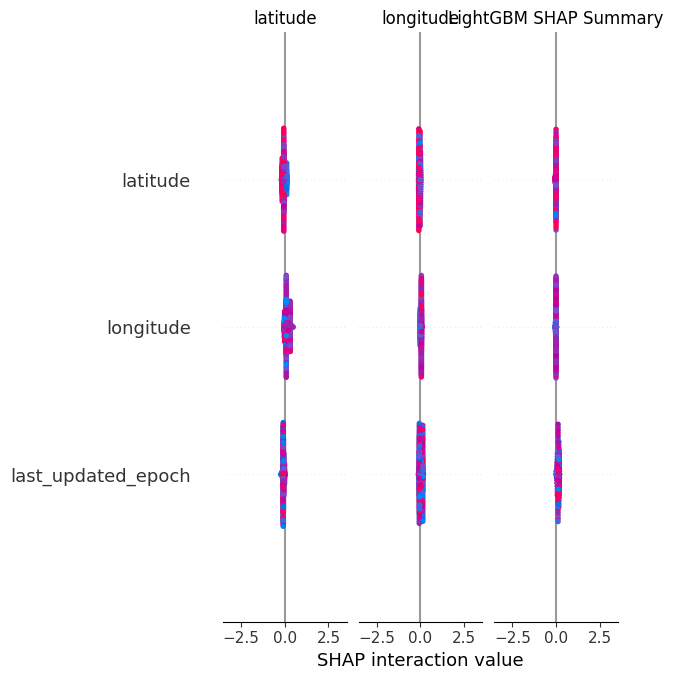


EXPLAINING CatBoost

=== GLOBAL EXPLANATION: CatBoost ===


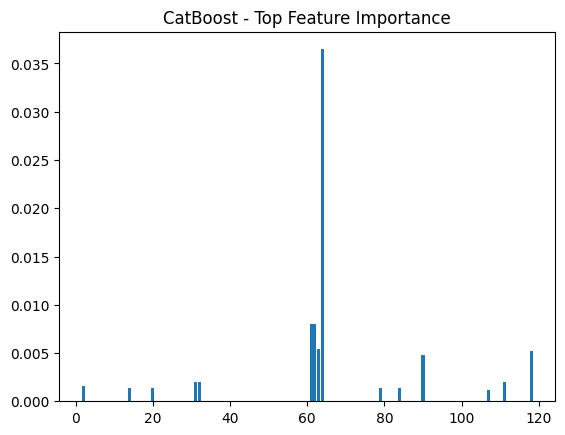


=== SHAP: CatBoost ===


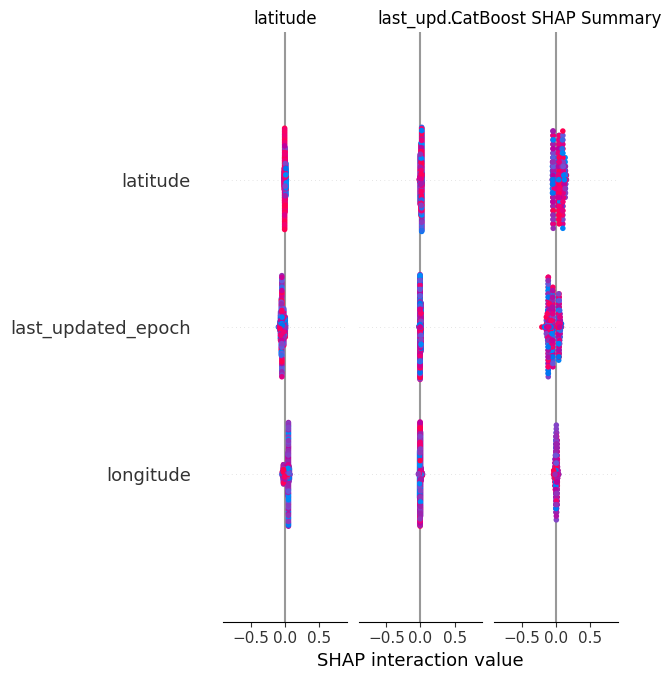


=== EXPLAINABILITY COMPLETE ===


In [110]:
run_explainability(models, X_train, X_test, y_train, y_test)